# 1. Library imports

In [1]:
import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import kstest, skew, kurtosis

from volatility_pipeline.models import (
    GARCHModel, make_garch, XGBVolatilityModel, XGBHybridModel,
    LSTMVolatilityModel, LSTMHybridModel,
    param_matrix,
    pvalue_matrix, asymmetry_summary, persistence, equations_markdown, scale_note,
)
from volatility_pipeline.evaluation import (
    RollingEvaluator,
    ForecastResult,
    dm_matrix,
    dm_family_split,
    mcs,
    arch_mcs,
    garman_klass,
    parkinson,
    squared_returns,
    forecast_diagnostics,
    normality_report,
)


# 2. Configuration

In [2]:
# ── Input data ───────────────────────────────────────────────────────────────
TICKER          = "NG=F"
FULL_DATA_START = "2010-01-01"
FULL_DATA_END   = "2025-06-30"

TRAIN_START = FULL_DATA_START
TRAIN_END   = "2024-12-31"
TEST_START  = "2025-01-01"
TEST_END    = FULL_DATA_END

# ── Classical econometric model specifications ────────────────────────────────
# Each tuple: (model_type, error_distribution)
# model_type:  'GARCH' | 'GJR-GARCH' | 'EGARCH' | 'APARCH' | 'FIGARCH'
# dist:        'normal' | 't' | 'ged'
GARCH_SPECS = [
    ("GARCH",     "normal"),
    ("GARCH",     "t"),
    ("GARCH",     "ged"),
    ("GJR-GARCH", "normal"),
    ("GJR-GARCH", "t"),
    ("GJR-GARCH", "ged"),
    ("EGARCH",    "normal"),
    ("EGARCH",    "t"),
    ("EGARCH",    "ged"),
    ("APARCH",    "normal"),
    ("APARCH",    "t"),
    ("APARCH",    "ged"),
    ("FIGARCH",   "normal"),
    ("FIGARCH",   "t"),
    ("FIGARCH",   "ged"),
]

# ASYM_ORDER sets the asymmetric (leverage) order `o` of the EGARCH and APARCH
# specifications, which are asymmetric by construction in the literature
# (Nelson 1991; Ding et al. 1993):
#   1 -> asymmetric: a leverage coefficient gamma is estimated (default)
#   0 -> symmetric variants instead (log-variance GARCH / plain Power ARCH)
# It is applied ONLY to EGARCH and APARCH. GARCH and GJR-GARCH are *defined* by
# o=0 and o=1 respectively (changing o would turn one into the other), and
# arch's FIGARCH has no asymmetric term — make_garch ignores the setting there.
# NOTE: arch_model()'s own default is o=0, so omitting it silently estimates the
# symmetric variant; that is why this is passed explicitly.
ASYM_ORDER = 1  # 1 | 0  — EGARCH / APARCH only

# ── Out-of-sample evaluation (shared by all models) ───────────────────────────
N_AHEAD     = 1   # forecast horizon; only 1 is currently supported
REFIT_EVERY = 10  # re-estimate parameters every N test steps

# WINDOW_TYPE controls the estimation scheme used during out-of-sample evaluation:
#   "expanding" — recursive: each step uses all data from the start up to t
#   "sliding"   — rolling: each step uses a fixed window of WINDOW_SIZE obs
WINDOW_TYPE = "expanding"  # 'expanding' | 'sliding'

# WINDOW_SIZE sets the sliding-window width in observations (ignored when
# WINDOW_TYPE="expanding"). None -> full training length (~3110 obs, ~12y),
# which overlaps almost entirely with the expanding window over a ~4y test and
# therefore shows negligible differences. Use a NARROW width to probe
# sensitivity to the 2020/2022 regime shifts, e.g. 750 (~3y) or 500 (~2y).
# NOTE: applies to every model group (GARCH, XGB, hybrid, LSTM) since they
# share the same evaluator settings; a narrow window also shortens each ML
# training set.
WINDOW_SIZE = None  # None | 750 | 500 | int (must be <= training length)

# VARIANCE_PROXY controls the realized-variance proxy used as the forecast target:
#   "garman_klass"  — Garman-Klass (1980): uses OHLC; 5-8x less noisy than r^2
#   "parkinson"     — Parkinson (1980): uses High/Low only; simpler than GK
#   "squared"       — r^2: noisiest, reduces DM/MCS power significantly
VARIANCE_PROXY = "garman_klass"  # 'garman_klass' | 'parkinson' | 'squared'

# ── Parallelism ───────────────────────────────────────────────────────────────
# Controls RollingEvaluator.evaluate_many(n_jobs=...).
#   1  → sequential (safe with any callable including lambdas)
#  -1  → all available CPU cores
#   N  → exactly N worker processes
#
# IMPORTANT — oversubscription rule:
#   PARALLEL_JOBS runs one process per model. Each XGB model internally uses
#   n_jobs=1 threads. Do NOT set both PARALLEL_JOBS > 1 AND override
#   XGB_PARAMS['n_jobs'] > 1 at the same time.
#
# NOTE — factory callables must be picklable when PARALLEL_JOBS != 1.
#   functools.partial (used below) is picklable. lambda is NOT.
PARALLEL_JOBS = -1   # -1 = all cores; change to 1 to run sequentially
print(f"CPUs available: {os.cpu_count()}  |  PARALLEL_JOBS={PARALLEL_JOBS}")

# ── Statistical tests ─────────────────────────────────────────────────────────
TEST_LOSS = "qlike"  # loss for DM test & MCS: 'squared' | 'absolute' | 'qlike'
MCS_ALPHA = 0.05     # MCS significance level
DM_ALPHA  = 0.05     # Diebold-Mariano rejection threshold

# ── Reproducibility ───────────────────────────────────────────────────────────
# RANDOM_SEED is passed to every bootstrap procedure (custom MCS and arch MCS).
# N_BOOT controls bootstrap replications; 2000 is a safe default.
RANDOM_SEED = 42
N_BOOT      = 2000

# ── Standalone XGBoost ────────────────────────────────────────────────────────
XGB_N_LAGS      = 10      # lagged sq-returns (and raw returns) as features
XGB_USE_RETURNS = True   # include lagged raw returns alongside sq-returns
XGB_USE_OPTUNA  = True   # Optuna hyperparameter search
XGB_N_TRIALS    = 50     # Optuna trials
XGB_OPTUNA_JOBS = 1      # parallel Optuna trials; keep 1 when PARALLEL_JOBS != 1
XGB_PARAMS      = None   # dict of manual XGBoost params; None → package defaults
                         # tip: add 'n_jobs': -1 here when PARALLEL_JOBS=1

# ── Hybrid XGBoost specifications ─────────────────────────────────────────────
# Each tuple: (garch_model_type, garch_dist, mode)
# mode 'features' : XGB predicts variance using GARCH forecast as one feature
# mode 'residual' : final forecast = GARCH_forecast + XGB_residual_correction
#
# Every permutation of GARCH_SPECS × mode (15 × 2 = 30 hybrids).
HYBRID_SPECS = [
    (gt, gd, mode)
    for gt, gd in GARCH_SPECS
    for mode in ["features"]
]

# HYBRID_SPECS = [
#     ("GARCH",     "normal", "features"),
#     ("GARCH",     "normal", "residual"),
#     ("GJR-GARCH", "t",      "features"),
#     ("GJR-GARCH", "t",      "residual"),
#     ("EGARCH",    "t",      "features"),
#     ("EGARCH",    "t",      "residual"),
# ]
HYBRID_N_LAGS      = 10
HYBRID_USE_RETURNS = True
HYBRID_USE_OPTUNA  = True
HYBRID_N_TRIALS    = 50
HYBRID_OPTUNA_JOBS = 1
HYBRID_PARAMS      = None
# ── LSTM — standalone & hybrid ────────────────────────────────────────────────
LSTM_LOOKBACK      = 20
LSTM_HIDDEN_SIZE   = 32
LSTM_NUM_LAYERS    = 1
LSTM_DROPOUT       = 0.2
LSTM_LR            = 1e-3
LSTM_MAX_EPOCHS    = 100
LSTM_PATIENCE      = 10
LSTM_BATCH_SIZE    = 32
LSTM_VAL_FRACTION  = 0.15
LSTM_WINSOR_LIMITS = (0.01, 0.01)
LSTM_DEVICE        = "cpu"  # None -> auto-select (cuda > mps > cpu)

# LSTM_RETRANSFORM maps the network's log-scale output back to variance units.
# The standalone LSTM and the 'features'-mode hybrid are trained on log(r^2)
# under MSE, so the network estimates E[log r^2 | X]. Exponentiating that gives
# the conditional GEOMETRIC mean, not the conditional variance E[r^2 | X] that
# every other model here forecasts and that RMSE / QLIKE score.
#   "smearing" -> Duan (1983) correction from the fit residuals (default)
#   "none"     -> plain exp(); on this data that is ~0.2x the realized level,
#                 which QLIKE punishes hard (-2.7 vs -6.2). Pre-fix behaviour.
# 'residual'-mode hybrids are fit on the level scale and are unaffected.
LSTM_RETRANSFORM   = "smearing"  # 'smearing' | 'none'

# Hybrid LSTM specifications: (garch_model_type, garch_dist, mode)
# mode 'features' : GARCH one-step forecast appended as an input feature/channel
# mode 'residual' : final forecast = GARCH_forecast + LSTM_residual_correction
LSTM_HYBRID_SPECS = HYBRID_SPECS

# Models run sequentially: MPS/CUDA hold a single device context, so
# RollingEvaluator(n_jobs=1) is required for LSTM model factories.
LSTM_PARALLEL_JOBS = -1


CPUs available: 10  |  PARALLEL_JOBS=-1


# 3. Data

In [3]:
# Import OHLC data from Yahoo Finance (needed for range-based variance proxies)
data   = yf.download(TICKER, start=FULL_DATA_START, end=FULL_DATA_END)
close  = data["Close"].squeeze()
open_  = data["Open"].squeeze()
high   = data["High"].squeeze()
low    = data["Low"].squeeze()

returns = np.log(close / close.shift(1)).dropna()

# Compute variance proxy on the original DatetimeIndex (before PeriodIndex conversion)
if VARIANCE_PROXY == "garman_klass":
    _proxy = garman_klass(
        open_.reindex(returns.index),
        high.reindex(returns.index),
        low.reindex(returns.index),
        close.reindex(returns.index),
    )
elif VARIANCE_PROXY == "parkinson":
    _proxy = parkinson(
        high.reindex(returns.index),
        low.reindex(returns.index),
    )
else:  # "squared"
    _proxy = squared_returns(returns)

# Convert both series to PeriodIndex for consistency with arch model indexing
returns.index = pd.PeriodIndex(returns.index, freq='D')
_proxy.index  = returns.index
variance_proxy = _proxy

print(f"Proxy: {VARIANCE_PROXY}  |  {len(variance_proxy)} observations")
print(f"  min={variance_proxy.min():.6e}  max={variance_proxy.max():.6e}  mean={variance_proxy.mean():.6e}")

[*********************100%***********************]  1 of 1 completed

Proxy: garman_klass  |  3894 observations
  min=1.151668e-06  max=9.273164e-02  mean=9.936202e-04


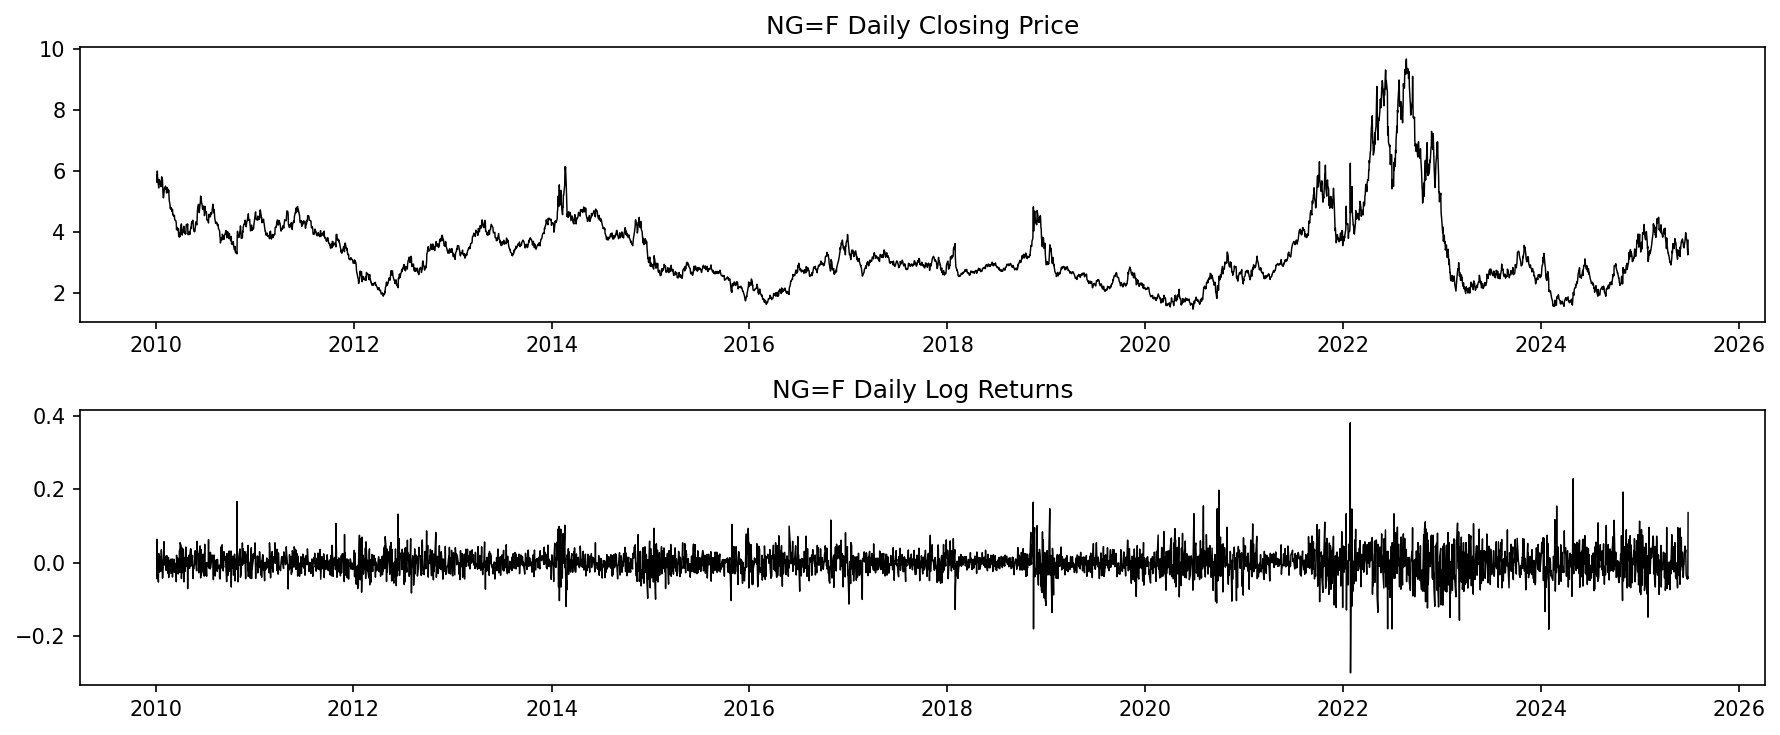

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=150)
axes[0].plot(close, linewidth=0.7, color='black')
axes[0].set_title(f"{TICKER} Daily Closing Price")
axes[1].plot(returns.index.to_timestamp(), returns.values, linewidth=0.7, color='black')
axes[1].set_title(f"{TICKER} Daily Log Returns")
plt.tight_layout()
plt.show()

In [5]:
def get_stats_and_ks(series, name):
    stats = series.describe()
    ks_stat, ks_pval = kstest(series, 'norm', args=(series.mean(), series.std()))
    return {
        'count': stats['count'], 'mean': stats['mean'], 'std': stats['std'],
        'min': stats['min'], 'max': stats['max'],
        'range': stats['max'] - stats['min'],
        'skewness': skew(series), 'kurtosis': kurtosis(series),
        'KS_stat': ks_stat, 'KS_pval': ks_pval, 'Name': name,
    }

stats_df = pd.DataFrame([get_stats_and_ks(returns, "Full Returns")]).set_index('Name')
stats_df

,count,mean,std,min,max,range,skewness,kurtosis,KS_stat,KS_pval
Name,,,,,,,,,,
Full Returns,3894.0,-0.000116,0.036043,-0.30048,0.381727,0.682207,0.241411,7.123881,0.058667,4.312409e-12


## 3.1 Normality and serial-dependence diagnostics

The KS statistic reported above assumes the observations are **i.i.d.** Daily returns are approximately uncorrelated in the mean (white noise) but *not* independent — they show volatility clustering (strong dependence in squared returns). Under that dependence the i.i.d. KS / Jarque–Bera null distributions are invalid and tend to over-reject. We therefore (Layer 1) document the dependence, (Layer 2) test normality with a dependence-robust test (Bai & Ng 2005, HAC-corrected skewness/kurtosis), and (Layer 3) recompute the KS p-value with a stationary block bootstrap; Anderson–Darling is added for tail sensitivity.

**How to read the dependence tests below.** Each test's H₀ is "no dependence of that kind, up to the tested lag." Rejecting H₀ (p < α) means the data show statistically significant evidence *of* the effect being tested; failing to reject (p > α) means no such evidence was found at that significance level — this does **not** prove the effect is absent, only that this test didn't detect it.

- **Ljung-Box (returns)** — H₀: no autocorrelation in returns (mean is white noise). We *expect* p > α here: if this rejects instead, the mean itself is predictable, which would be a problem for the modelling that follows.
- **Ljung-Box (squared returns)** — H₀: no autocorrelation in squared returns. We *expect* p < α (a rejection) here — this is the volatility-clustering signal that motivates GARCH modelling in the first place.
- **Engle ARCH-LM** — H₀: no ARCH effects (squared returns are not linearly predictable from their own recent lags). Same expectation: p < α confirms ARCH effects are present.


In [6]:
# Layers 1-3 normality / serial-dependence diagnostics (see markdown above).
# Volatility clustering makes the i.i.d. KS test invalid; these address that.
norm_diag = normality_report(returns, name=TICKER, n_boot=N_BOOT, seed=RANDOM_SEED)

# Layer 1 - dependence: mean ~ white noise, variance strongly dependent
# (this is exactly why an i.i.d. distributional test on the levels is invalid).
norm_diag["dependence"].style.format(
    {"statistic": "{:.2f}", "p_value": "{:.2e}"}
).set_caption("Layer 1 - serial dependence: Ljung-Box (returns & squared) + Engle ARCH-LM")

,series,test,lag,statistic,p_value
0,NG=F,Ljung-Box (returns),10,55.67,2.36e-08
1,NG=F,Ljung-Box (returns),20,71.28,1.12e-07
2,NG=F,Ljung-Box (squared returns),10,621.10,5.30e-127
3,NG=F,Ljung-Box (squared returns),20,756.96,1.91e-147
4,NG=F,Engle ARCH-LM,10,428.95,6.43e-86


**How to read the normality tests below.** Every test here shares the same H₀: *the returns are normally distributed.*

- **p < α → reject H₀**: statistically significant evidence *against* normality — the typical, expected finding for daily financial returns (fat tails, occasional skew).
- **p > α → fail to reject H₀**: no evidence against normality was found at this significance level. This does **not** prove normality, only that this particular test could not detect a departure from it.

The **orange** tests (Jarque-Bera, classical KS) assume i.i.d. data — which Layer 1 above shows is violated here — so their p-values are typically **too small** (over-rejection); a rejection there alone is not trustworthy on its own. The **green** tests (Bai-Ng HAC, block-bootstrap KS) stay valid under the dependence just documented, so their p-values are the ones to actually report and interpret.

In [7]:
# Layers 2-3 - normality under dependence. Naive i.i.d. tests (Jarque-Bera,
# classical KS) over-reject; the dependence-robust tests (Bai-Ng HAC joint,
# block-bootstrap KS) plus Anderson-Darling give valid evidence of non-normality.
def _hl_norm(row):
    # Explicit text colour alongside the background: the pastel backgrounds
    # need dark text for contrast, but VS Code's dark theme overrides default
    # text to white, making it unreadable without forcing the colour here.
    a = str(row["assumption"])
    if "robust" in a:
        style = "background-color: #2e7d32; color: #ffffff"   # dependence-robust
    elif "invalid" in a:
        style = "background-color: #bf360c; color: #ffffff"   # i.i.d., invalid here
    else:
        style = ""
    return [style] * len(row)

norm_diag["normality"].style.apply(_hl_norm, axis=1).format(
    {"statistic": "{:.3f}", "p_value": "{:.2e}"}, na_rep="-"
).set_caption("Layers 2-3 - normality: i.i.d. (orange/white text, invalid) vs dependence-robust (green/white text)")

,series,test,assumption,statistic,p_value
0,NG=F,Jarque-Bera,i.i.d. (invalid here),8271.958,0.00e+00
1,NG=F,Bai-Ng joint (HAC),dependence-robust,4.154,1.25e-01
2,NG=F,Bai-Ng skewness (HAC),dependence-robust,1.115,2.65e-01
3,NG=F,Bai-Ng kurtosis (HAC),dependence-robust,1.707,8.79e-02
4,NG=F,KS vs Normal,i.i.d. (invalid here),0.059,4.31e-12
5,NG=F,KS vs Normal (block-bootstrap),dependence-robust,0.059,5.00e-04
6,NG=F,Anderson-Darling,i.i.d.; crit@5%=0.752,29.560,-


In [8]:
train_returns = returns[returns.index <= TRAIN_END]
test_returns  = returns[(returns.index >= TEST_START) & (returns.index <= TEST_END)]

print(f"Train: {train_returns.index[0]}  →  {train_returns.index[-1]}  ({len(train_returns)} obs)")
print(f"Test:  {test_returns.index[0]}  →  {test_returns.index[-1]}  ({len(test_returns)} obs)")

Train: 2010-01-05  →  2024-12-31  (3772 obs)
Test:  2025-01-02  →  2025-06-27  (122 obs)


# 4. Classical Econometric Models (GARCH Family)

Five volatility specifications × three error distributions = 15 models.

| Spec | Description |
|------|-------------|
| GARCH | Standard symmetric GARCH(1,1) — Bollerslev (1986) |
| GJR-GARCH | Asymmetric leverage effect via indicator term — Glosten et al. (1993) |
| EGARCH | Log-variance equation, asymmetric leverage term (`o=ASYM_ORDER`) — Nelson (1991) |
| APARCH | Asymmetric power ARCH, leverage term (`o=ASYM_ORDER`) — Ding et al. (1993) |
| FIGARCH | Fractionally integrated long-memory variance — Baillie et al. (1996) |

## 4.1 In-sample fit

In [9]:
insample_models: dict[str, GARCHModel] = {}
ic_rows = []

for model_type, dist in GARCH_SPECS:
    name  = f"{model_type}-{dist.upper()}"
    model = make_garch(model_type, dist, asym_order=ASYM_ORDER)
    try:
        model.fit(train_returns)
        insample_models[name] = model
        row = model.info_criteria()
        row["Model"] = name
        ic_rows.append(row)
    except Exception as exc:
        print(f"  [WARNING] {name} failed: {exc}")

ic_df = (
    pd.DataFrame(ic_rows)
    .set_index("Model")
    .sort_values("BIC")
    [["LogL", "AIC", "BIC"]]
)
print(f"Fitted {len(insample_models)} / {len(GARCH_SPECS)} models")
ic_df

Fitted 15 / 15 models


,LogL,AIC,BIC
Model,,,
EGARCH-T,-9556.955368,19125.910735,19163.322899
GARCH-T,-9563.783997,19137.567995,19168.744798
APARCH-T,-9557.898216,19129.796433,19173.443957
FIGARCH-T,-9562.942131,19137.884262,19175.296426
GJR-GARCH-T,-9563.301607,19138.603213,19176.015377
GARCH-GED,-9589.801593,19189.603186,19220.779989
EGARCH-GED,-9587.444613,19186.889226,19224.301390
FIGARCH-GED,-9588.978045,19189.956090,19227.368254
GJR-GARCH-GED,-9589.795434,19191.590868,19229.003032


### 4.1.1 Estimated equations and coefficient significance

The information criteria above say which specification fits better, but not *why* — for that the estimated coefficients and their standard errors are needed. This subsection reports them, and in particular lets us check whether the asymmetry (leverage) coefficient is statistically distinguishable from zero: if it is not, an asymmetric specification is effectively equivalent to its symmetric counterpart, which would explain a better in-sample fit that does not translate into better forecasts.

**Reading the tables.** Coefficients are estimated on returns in **percent** (log-returns × 100), the conventional scaling; slope coefficients (α, β, γ, d, φ, δ) are scale-free, while the intercepts (μ, ω) are on the percent scale. Standard errors are in brackets and stars mark significance (\*\*\* p<0.01, \*\* p<0.05, \* p<0.10). An empty cell means the parameter does not exist in that specification (e.g. `gamma[1]` in a symmetric model, `nu` in a Normal one). A companion table below gives the exact p-value for every coefficient instead of just the stars, for citing precise values.

**H₀ for each coefficient** is that the true value is zero. Rejecting it (small p) means the term contributes; failing to reject means the data cannot distinguish that term's effect from zero — which for γ is exactly the "is the asymmetry parameter redundant?" question.

In [10]:
# Estimated coefficients, publication style: "coef (std_err)" with significance stars.
# Empty cell = parameter not present in that specification.
coef_matrix = param_matrix(insample_models)
print(scale_note(insample_models))
print()
coef_matrix

Coefficients are estimated on returns expressed in percent (log-returns x 100), the conventional scaling in the GARCH literature. Slope coefficients (alpha, beta, gamma, d, phi, delta) are scale-free; the intercepts (mu, omega) are on the percent scale. Standard errors in brackets; *** p<0.01, ** p<0.05, * p<0.10.



parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.0283 (0.0456),0.0918*** (0.0334),0.0826*** (0.0109),,0.9147*** (0.0100),,,,,
GARCH-T,-0.0225 (0.0424),0.1101*** (0.0284),0.0730*** (0.0087),,0.9197*** (0.0087),,,,,7.4799*** (0.8500)
GARCH-GED,-0.0091 (0.0445),0.1033*** (0.0298),0.0772*** (0.0094),,0.9172*** (0.0091),,,,,1.4667*** (0.0577)
GJR-GARCH-NORMAL,0.0205 (0.0441),0.0930*** (0.0334),0.0791*** (0.0124),0.0094 (0.0190),0.9136*** (0.0101),,,,,
GJR-GARCH-T,-0.0164 (0.0428),0.1086*** (0.0284),0.0786*** (0.0110),-0.0138 (0.0146),0.9209*** (0.0088),,,,,7.4396*** (0.8402)
GJR-GARCH-GED,-0.0083 (0.0449),0.1031*** (0.0299),0.0777*** (0.0113),-0.0015 (0.0161),0.9173*** (0.0092),,,,,1.4664*** (0.0572)
EGARCH-NORMAL,0.0221 (0.0436),0.0289*** (0.0102),0.1754*** (0.0215),0.0035 (0.0137),0.9902*** (0.0044),,,,,
EGARCH-T,-0.0114 (0.0423),0.0298*** (0.0074),0.1549*** (0.0153),0.0149 (0.0108),0.9890*** (0.0030),,,,,7.2894*** (0.8105)
EGARCH-GED,-0.0075 (0.0445),0.0295*** (0.0084),0.1641*** (0.0176),0.0085 (0.0118),0.9894*** (0.0035),,,,,1.4541*** (0.0583)


In [11]:
# Companion table: the exact p-value for every coefficient (not just the
# significance stars above) — useful for citing precise values and for
# borderline cases the *** / ** / * buckets collapse together.
pval_matrix = pvalue_matrix(insample_models, decimals=4)

def _hl_pval(v):
    # same green used for the normality diagnostics, for a consistent and
    # dark-theme-readable "this is significant" signal across the notebook.
    if isinstance(v, (int, float)) and np.isfinite(v) and v < 0.05:
        return "background-color: #2e7d32; color: #ffffff"
    return ""

pval_matrix.style.map(_hl_pval).format(precision=4, na_rep="-").set_caption(
    "Exact p-values per parameter (green = significant at 5%; blank = parameter not in this specification)"
)

parameter,mu,omega,alpha[1],gamma[1],beta[1],phi,d,beta,delta,nu
model,,,,,,,,,,
GARCH-NORMAL,0.5353,0.0060,0.0000,-,0.0000,-,-,-,-,-
GARCH-T,0.5956,0.0001,0.0000,-,0.0000,-,-,-,-,0.0000
GARCH-GED,0.8372,0.0005,0.0000,-,0.0000,-,-,-,-,0.0000
GJR-GARCH-NORMAL,0.6424,0.0054,0.0000,0.6199,0.0000,-,-,-,-,-
GJR-GARCH-T,0.7011,0.0001,0.0000,0.3432,0.0000,-,-,-,-,0.0000
GJR-GARCH-GED,0.8532,0.0006,0.0000,0.9238,0.0000,-,-,-,-,0.0000
EGARCH-NORMAL,0.6127,0.0047,0.0000,0.8014,0.0000,-,-,-,-,-
EGARCH-T,0.7877,0.0001,0.0000,0.1657,0.0000,-,-,-,-,0.0000
EGARCH-GED,0.8664,0.0004,0.0000,0.4713,0.0000,-,-,-,-,0.0000


In [12]:
# Is the asymmetry (leverage) parameter redundant? Direct per-model verdict.
# NOTE: models reported as "no asymmetry parameter estimated" have no gamma in
# their fitted parameter vector, so they are symmetric AS CONFIGURED — worth
# checking against what each specification is intended to capture.
asym_df = asymmetry_summary(insample_models, alpha=0.05)

_n_asym = int(asym_df["has_asymmetry"].sum())
_n_sig = int(asym_df["significant"].sum())
print(f"Models with an estimated asymmetry parameter: {_n_asym} / {len(asym_df)}")
print(f"  of which significant at 5%: {_n_sig}")
print()

asym_df[["has_asymmetry", "coef", "std_err", "t_stat", "p_value", "significant", "verdict"]]

Models with an estimated asymmetry parameter: 9 / 15
  of which significant at 5%: 0



,has_asymmetry,coef,std_err,t_stat,p_value,significant,verdict
GARCH-NORMAL,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-T,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GARCH-GED,False,NaN,NaN,NaN,NaN,False,no asymmetry parameter estimated
GJR-GARCH-NORMAL,True,0.009433,0.019017,0.496023,0.619878,False,not distinguishable from 0 -> effectively symm...
GJR-GARCH-T,True,-0.013795,0.014555,-0.947788,0.343237,False,not distinguishable from 0 -> effectively symm...
GJR-GARCH-GED,True,-0.001536,0.016054,-0.095696,0.923762,False,not distinguishable from 0 -> effectively symm...
EGARCH-NORMAL,True,0.003452,0.013726,0.251497,0.80143,False,not distinguishable from 0 -> effectively symm...
EGARCH-T,True,0.014938,0.010776,1.386212,0.165682,False,not distinguishable from 0 -> effectively symm...
EGARCH-GED,True,0.008521,0.011829,0.720394,0.471282,False,not distinguishable from 0 -> effectively symm...
APARCH-NORMAL,True,0.021526,0.066387,0.324243,0.745754,False,not distinguishable from 0 -> effectively symm...


In [13]:
# Volatility persistence, using the measure appropriate to each specification
# (alpha+beta for GARCH, alpha+beta+gamma/2 for GJR, beta for EGARCH's log-variance
# AR, and the long-memory parameter d for FIGARCH). Values are comparable only
# within the same measure.
persistence(insample_models)

,measure,value
GARCH-NORMAL,alpha+beta,0.997303
GARCH-T,alpha+beta,0.992725
GARCH-GED,alpha+beta,0.994337
GJR-GARCH-NORMAL,alpha+beta+gamma/2,0.997378
GJR-GARCH-T,alpha+beta+gamma/2,0.992617
GJR-GARCH-GED,alpha+beta+gamma/2,0.994321
EGARCH-NORMAL,beta (log-variance AR),0.990177
EGARCH-T,beta (log-variance AR),0.989013
EGARCH-GED,beta (log-variance AR),0.989404
APARCH-NORMAL,n/a (no closed form),NaN


In [14]:
# Fitted mean and variance equations, with the estimated coefficients substituted.
# The variance equation shown reflects the specification AS ESTIMATED — an
# asymmetry term appears only where an asymmetry coefficient was actually fitted.
from IPython.display import Markdown, display

display(Markdown(equations_markdown(insample_models, decimals=4)))

$$\begin{aligned} \textbf{GARCH-NORMAL} \\[2pt] r_t = 0.0283 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.0918 + 0.0826\,\varepsilon_{t-1}^2 + 0.9147\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-T} \\[2pt] r_t = -0.0225 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1101 + 0.0730\,\varepsilon_{t-1}^2 + 0.9197\,\sigma_{t-1}^2 \\[2pt] \nu = 7.4799 \end{aligned}$$

$$\begin{aligned} \textbf{GARCH-GED} \\[2pt] r_t = -0.0091 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1033 + 0.0772\,\varepsilon_{t-1}^2 + 0.9172\,\sigma_{t-1}^2 \\[2pt] \nu = 1.4667 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-NORMAL} \\[2pt] r_t = 0.0205 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.0930 + 0.0791\,\varepsilon_{t-1}^2 + 0.0094\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9136\,\sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-T} \\[2pt] r_t = -0.0164 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1086 + 0.0786\,\varepsilon_{t-1}^2 - 0.0138\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9209\,\sigma_{t-1}^2 \\[2pt] \nu = 7.4396 \end{aligned}$$

$$\begin{aligned} \textbf{GJR-GARCH-GED} \\[2pt] r_t = -0.0083 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1031 + 0.0777\,\varepsilon_{t-1}^2 - 0.0015\,\varepsilon_{t-1}^2\,\mathbb{1}_{\{\varepsilon_{t-1} < 0\}} + 0.9173\,\sigma_{t-1}^2 \\[2pt] \nu = 1.4664 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-NORMAL} \\[2pt] r_t = 0.0221 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \ln \sigma_t^2 = 0.0289 + 0.1754\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0035\,z_{t-1} + 0.9902\,\ln \sigma_{t-1}^2 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-T} \\[2pt] r_t = -0.0114 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \ln \sigma_t^2 = 0.0298 + 0.1549\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0149\,z_{t-1} + 0.9890\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 7.2894 \end{aligned}$$

$$\begin{aligned} \textbf{EGARCH-GED} \\[2pt] r_t = -0.0075 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \ln \sigma_t^2 = 0.0295 + 0.1641\left(|z_{t-1}| - \mathbb{E}|z_{t-1}|\right) + 0.0085\,z_{t-1} + 0.9894\,\ln \sigma_{t-1}^2 \\[2pt] \nu = 1.4541 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-NORMAL} \\[2pt] r_t = 0.0208 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^{1.8131} = 0.0840 + 0.0846\,\left(|\varepsilon_{t-1}| - 0.0215\,\varepsilon_{t-1}\right)^{1.8131} + 0.9154\,\sigma_{t-1}^{1.8131} \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-T} \\[2pt] r_t = -0.0127 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^{1.4671} = 0.0708 + 0.0759\,\left(|\varepsilon_{t-1}| + 0.0884\,\varepsilon_{t-1}\right)^{1.4671} + 0.9241\,\sigma_{t-1}^{1.4671} \\[2pt] \nu = 7.5291 \end{aligned}$$

$$\begin{aligned} \textbf{APARCH-GED} \\[2pt] r_t = -0.0069 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^{1.6305} = 0.0783 + 0.0797\,\left(|\varepsilon_{t-1}| + 0.0254\,\varepsilon_{t-1}\right)^{1.6305} + 0.9203\,\sigma_{t-1}^{1.6305} \\[2pt] \nu = 1.4653 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-NORMAL} \\[2pt] r_t = 0.0283 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathcal{N}(0,1) \\[2pt] \sigma_t^2 = 0.1035 + 0.8846\,\sigma_{t-1}^2 + \left[1 - 0.8846L - (1 - 0.0256L)(1-L)^{0.9248}\right]\varepsilon_t^2 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-T} \\[2pt] r_t = -0.0220 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim t_{\nu} \\[2pt] \sigma_t^2 = 0.1056 + 0.8910\,\sigma_{t-1}^2 + \left[1 - 0.8910L - (1 - 0.0000L)(1-L)^{0.9320}\right]\varepsilon_t^2 \\[2pt] \nu = 7.0759 \end{aligned}$$

$$\begin{aligned} \textbf{FIGARCH-GED} \\[2pt] r_t = -0.0090 + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim \mathrm{GED}(\nu) \\[2pt] \sigma_t^2 = 0.1040 + 0.8849\,\sigma_{t-1}^2 + \left[1 - 0.8849L - (1 - 0.0149L)(1-L)^{0.9224}\right]\varepsilon_t^2 \\[2pt] \nu = 1.4615 \end{aligned}$$

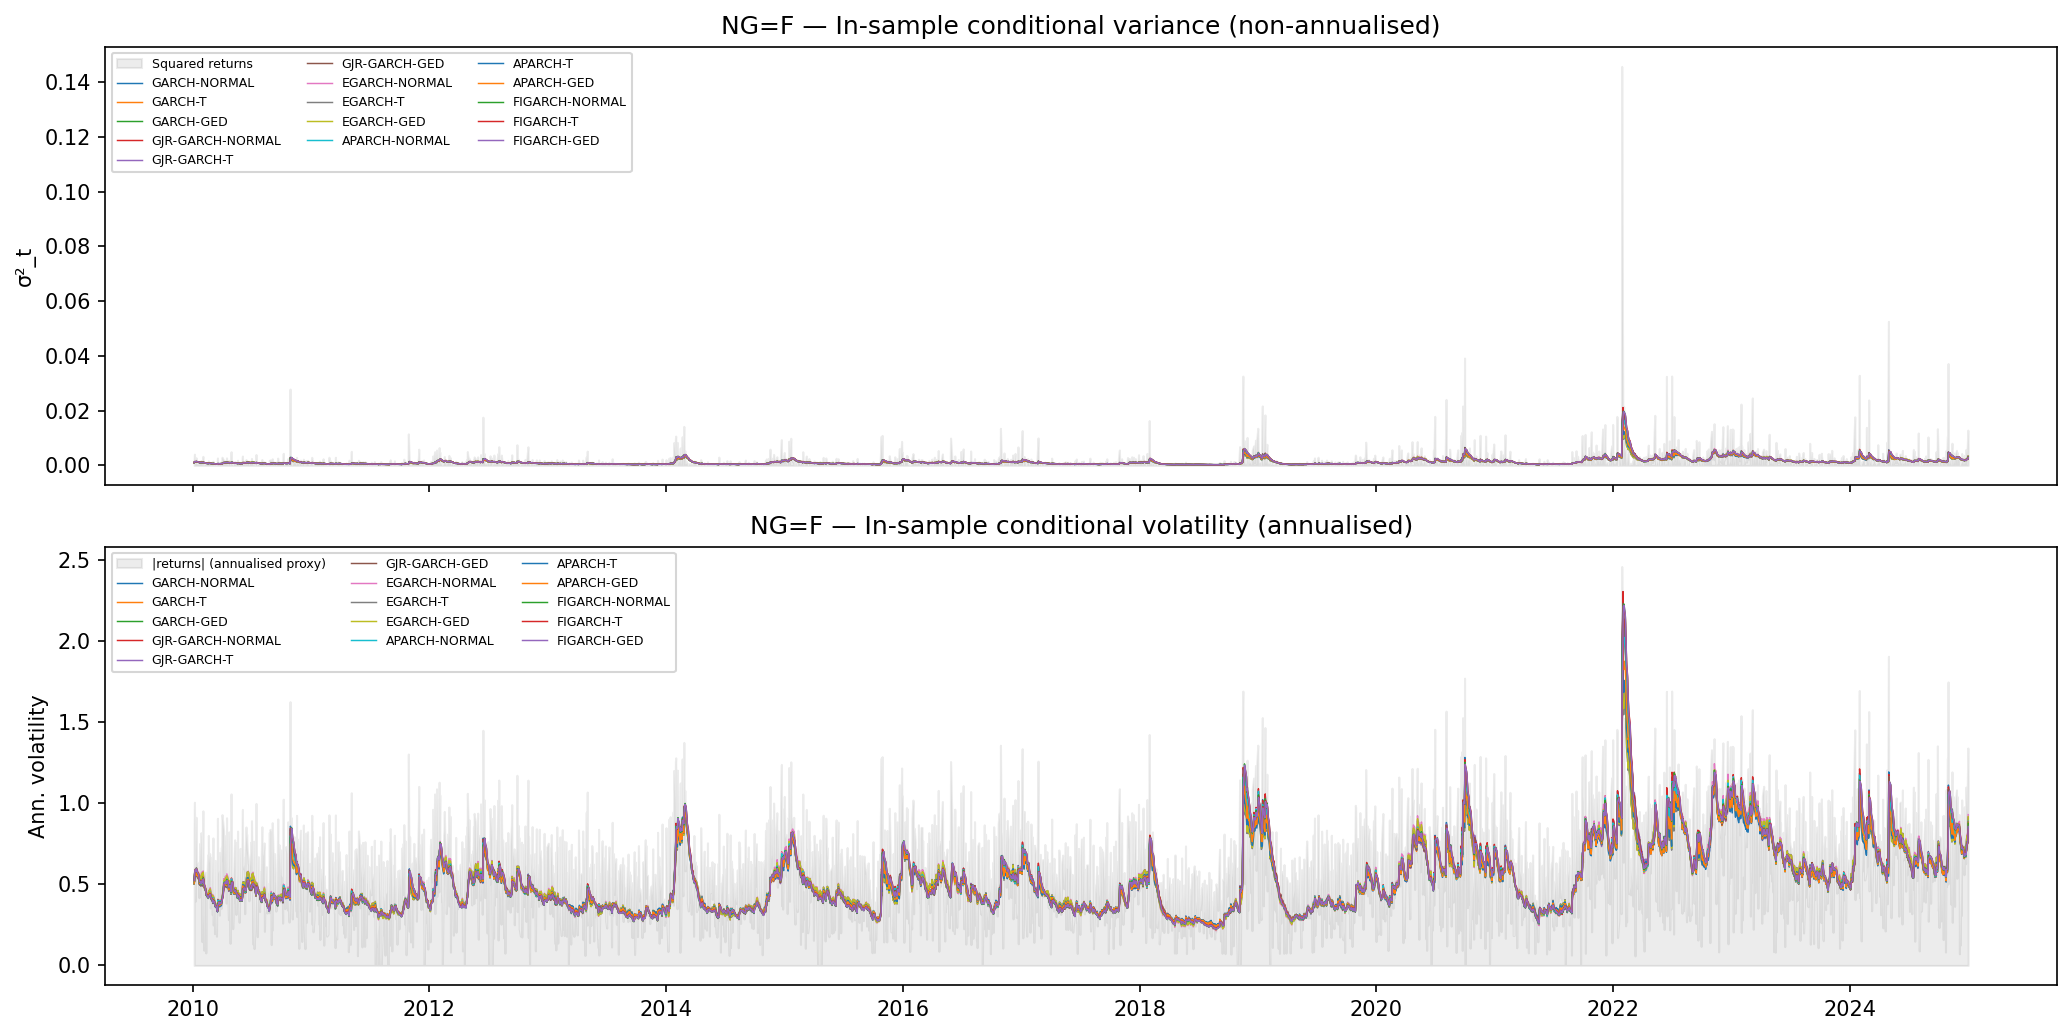

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), dpi=150, sharex=True)

# Raw variance
axes[0].fill_between(
    train_returns.index.to_timestamp(),
    train_returns.values ** 2,
    alpha=0.15, color="gray", label="Squared returns",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[0].plot(cv.index.to_timestamp(), cv.values, linewidth=0.7, label=name)
axes[0].set_title(f"{TICKER} — In-sample conditional variance (non-annualised)")
axes[0].set_ylabel("σ²_t")
axes[0].legend(fontsize=6, ncol=3)

# Annualised volatility
axes[1].fill_between(
    train_returns.index.to_timestamp(),
    np.sqrt(np.abs(train_returns.values) * np.sqrt(252)),
    alpha=0.15, color="gray", label="|returns| (annualised proxy)",
)
for name, model in insample_models.items():
    cv = model.insample_variance()
    axes[1].plot(cv.index.to_timestamp(), np.sqrt(cv.values * 252), linewidth=0.7, label=name)
axes[1].set_title(f"{TICKER} — In-sample conditional volatility (annualised)")
axes[1].set_ylabel("Ann. volatility")
axes[1].legend(fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

## 4.2 Out-of-sample evaluation

Window scheme controlled by `WINDOW_TYPE` (expanding or sliding), 1-step-ahead.  
Parameters re-estimated every `REFIT_EVERY` steps.  
Realized variance proxy controlled by `VARIANCE_PROXY` (default: Garman-Klass).

In [16]:
evaluator = RollingEvaluator(
    n_ahead=N_AHEAD, refit_every=REFIT_EVERY,
    window_type=WINDOW_TYPE, window_size=WINDOW_SIZE,
)

# functools.partial is picklable — required when PARALLEL_JOBS != 1.
# lambda would work for sequential (n_jobs=1) but cannot be sent to worker processes.
garch_eval_specs = [
    (partial(make_garch, t, d, asym_order=ASYM_ORDER), f"{t}-{d.upper()}")
    for t, d in GARCH_SPECS
]

garch_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    garch_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=PARALLEL_JOBS,
)
_width = WINDOW_SIZE if (WINDOW_TYPE == "sliding" and WINDOW_SIZE is not None) else (
    len(train_returns) if WINDOW_TYPE == "sliding" else "n/a"
)
print(f"\nCompleted {len(garch_results)} GARCH models.")
print(f"Window type: {WINDOW_TYPE}  |  Window size: {_width}  |  Proxy: {VARIANCE_PROXY}")

Parallel evaluation: 15 models on 10 worker process(es)...
  [GARCH-NORMAL] done  RMSE=1.6223e-03
  [GARCH-T] done  RMSE=1.5260e-03
  [GJR-GARCH-NORMAL] done  RMSE=1.6510e-03
  [GARCH-GED] done  RMSE=1.5624e-03
  [GJR-GARCH-T] done  RMSE=1.4941e-03
  [EGARCH-NORMAL] done  RMSE=1.6003e-03
  [GJR-GARCH-GED] done  RMSE=1.5601e-03
  [EGARCH-T] done  RMSE=1.4832e-03
  [EGARCH-GED] done  RMSE=1.5305e-03
  [APARCH-NORMAL] done  RMSE=1.6059e-03
  [APARCH-GED] done  RMSE=1.5007e-03
  [APARCH-T] done  RMSE=1.4281e-03
  [FIGARCH-NORMAL] done  RMSE=1.6004e-03
  [FIGARCH-T] done  RMSE=1.5043e-03
  [FIGARCH-GED] done  RMSE=1.5610e-03

Completed 15 GARCH models.
Window type: expanding  |  Window size: n/a  |  Proxy: garman_klass


In [17]:
garch_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in garch_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
garch_metrics_df

,RMSE,MAE,MSE,QLIKE
APARCH-T,0.001428,0.001170,0.000002,-5.402539
EGARCH-T,0.001483,0.001229,0.000002,-5.392566
GJR-GARCH-T,0.001494,0.001225,0.000002,-5.391981
APARCH-GED,0.001501,0.001222,0.000002,-5.391847
FIGARCH-T,0.001504,0.001264,0.000002,-5.384352
GARCH-T,0.001526,0.001238,0.000002,-5.389750
EGARCH-GED,0.001530,0.001263,0.000002,-5.385134
GJR-GARCH-GED,0.001560,0.001266,0.000002,-5.383972
FIGARCH-GED,0.001561,0.001312,0.000002,-5.373593
GARCH-GED,0.001562,0.001267,0.000002,-5.383789


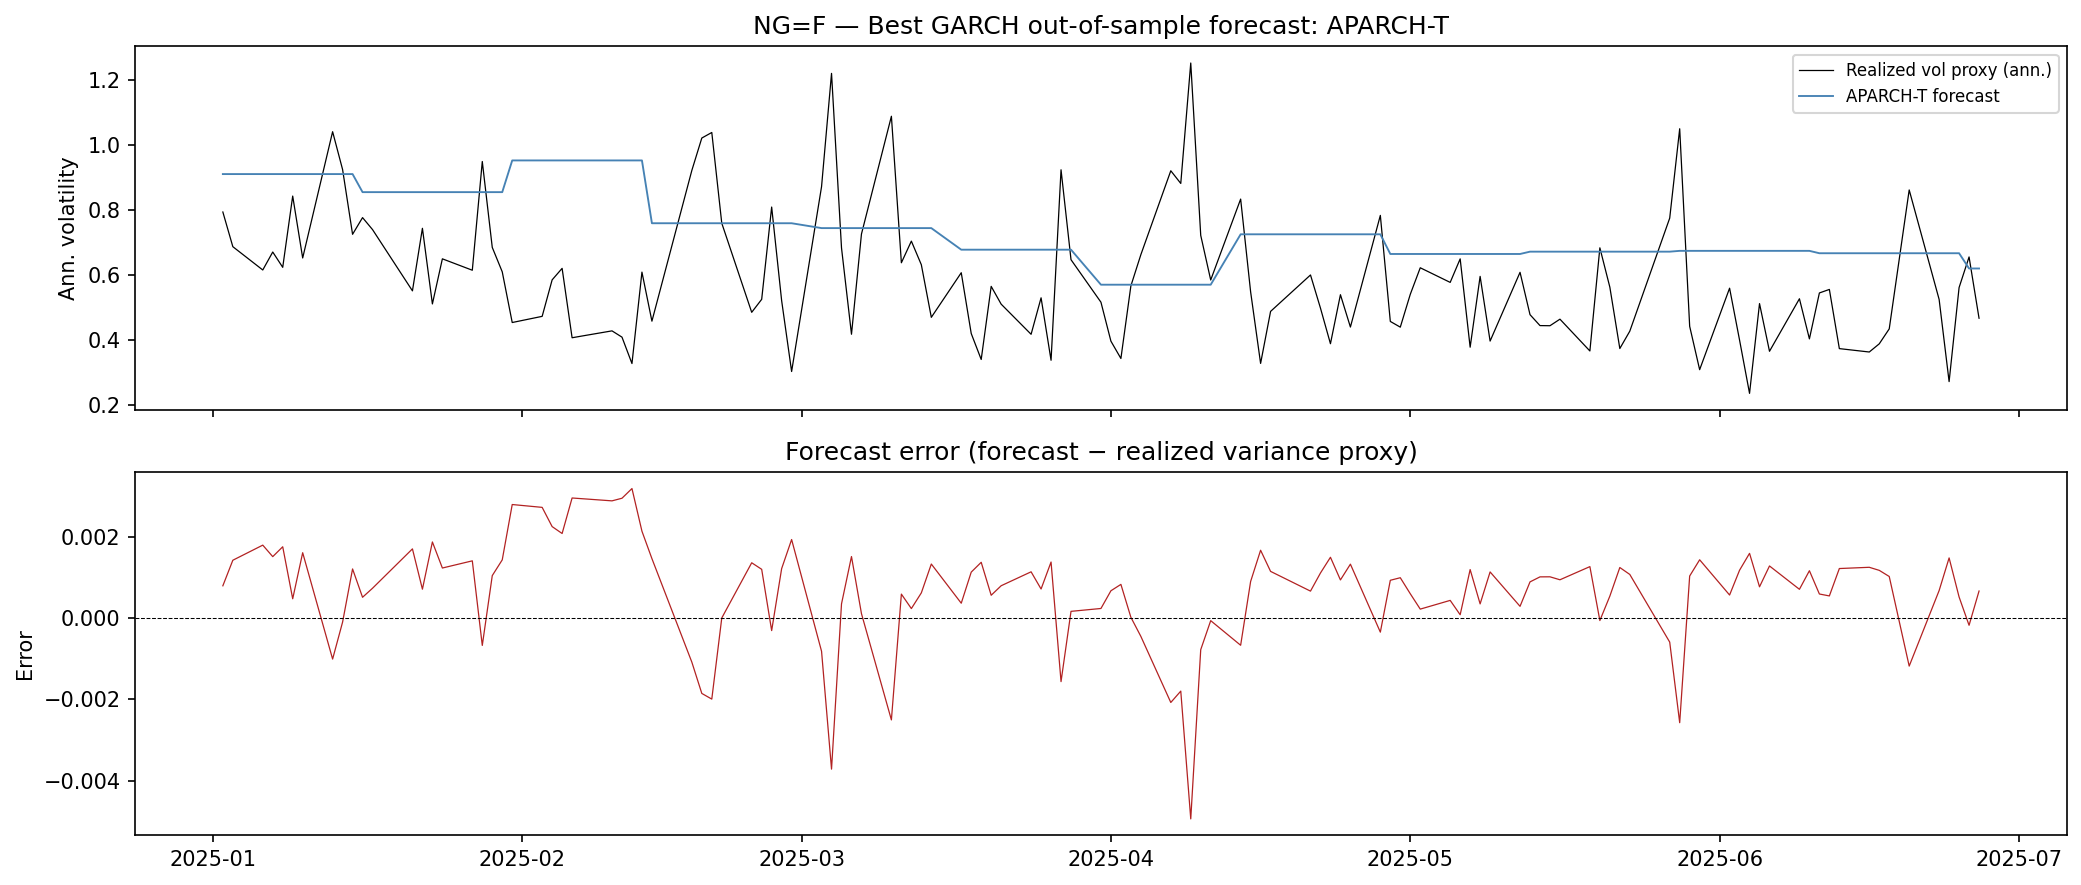

In [18]:
best_garch_name = garch_metrics_df.index[0]
r = garch_results[best_garch_name]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r.actuals.index.to_timestamp(), np.sqrt(r.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
             color='steelblue', linewidth=0.9, label=f'{best_garch_name} forecast')
axes[0].set_title(f"{TICKER} — Best GARCH out-of-sample forecast: {best_garch_name}")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r.errors.index.to_timestamp(), r.errors.values, color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

# 5. Standalone XGBoost

XGBoost regressor trained directly on lagged squared returns (realized variance proxies) and, optionally, lagged raw returns.  
No distributional assumptions — the model learns the mapping from lagged features to next-step variance.  
Hyperparameters can be tuned via Optuna (set `XGB_USE_OPTUNA = True` in config).

## 5.1 Out-of-sample evaluation

In [19]:
xgb_eval_specs = [
    (
        partial(XGBVolatilityModel,
                n_lags=XGB_N_LAGS,
                use_returns=XGB_USE_RETURNS,
                use_optuna=XGB_USE_OPTUNA,
                n_trials=XGB_N_TRIALS,
                optuna_n_jobs=XGB_OPTUNA_JOBS,
                xgb_params=XGB_PARAMS),
        "XGB-Standalone",
    )
]

xgb_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    xgb_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=1,   # single model — no benefit from spawning a process
)
print(f"\nCompleted {len(xgb_results)} standalone XGB model(s).")

Evaluating XGB-Standalone...


/opt/anaconda3/envs/volatility-pipeline-new/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  [XGB-Standalone] re-fitted at step 0/122 (expanding)
  [XGB-Standalone] re-fitted at step 10/122 (expanding)
  [XGB-Standalone] re-fitted at step 20/122 (expanding)
  [XGB-Standalone] re-fitted at step 30/122 (expanding)
  [XGB-Standalone] re-fitted at step 40/122 (expanding)
  [XGB-Standalone] re-fitted at step 50/122 (expanding)
  [XGB-Standalone] re-fitted at step 60/122 (expanding)
  [XGB-Standalone] re-fitted at step 70/122 (expanding)
  [XGB-Standalone] re-fitted at step 80/122 (expanding)
  [XGB-Standalone] re-fitted at step 90/122 (expanding)
  [XGB-Standalone] re-fitted at step 100/122 (expanding)
  [XGB-Standalone] re-fitted at step 110/122 (expanding)
  [XGB-Standalone] re-fitted at step 120/122 (expanding)

Completed 1 standalone XGB model(s).


In [20]:
xgb_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in xgb_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
xgb_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-Standalone,0.00145,0.001149,0.000002,-5.350662


## 5.2 Feature importance

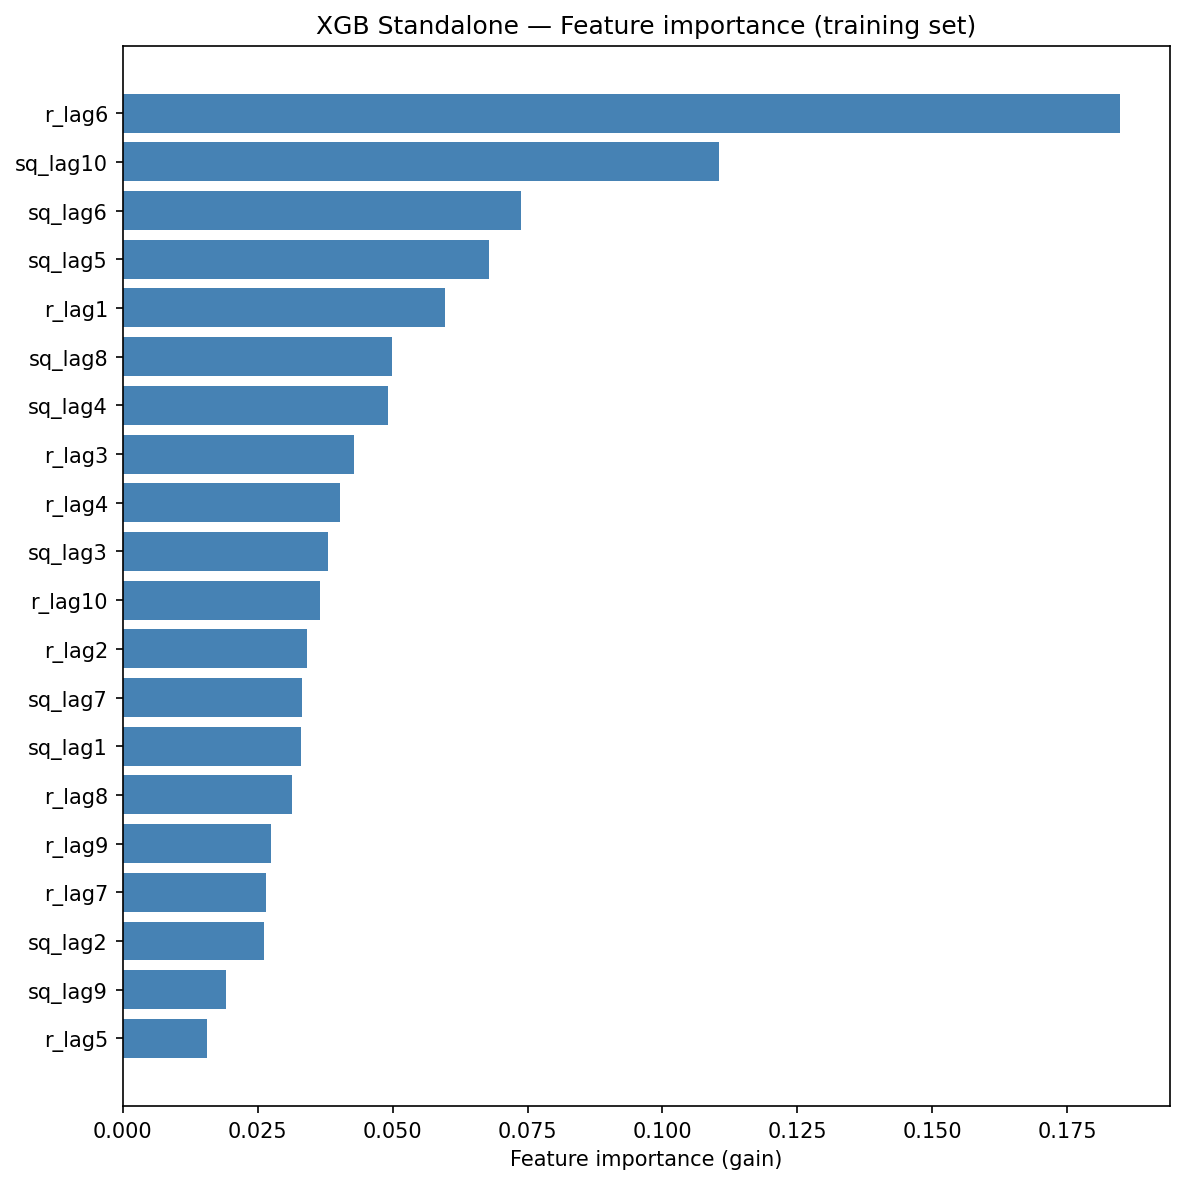

In [21]:
# Fit once on training data for inspection (separate from the rolling evaluation)
xgb_viz = XGBVolatilityModel(
    n_lags=XGB_N_LAGS, use_returns=XGB_USE_RETURNS,
    use_optuna=False, xgb_params=XGB_PARAMS,
)
xgb_viz.fit(train_returns)

feat_names   = xgb_viz.feature_names()
importances  = xgb_viz._model.feature_importances_
order        = np.argsort(importances)

fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
ax.barh([feat_names[i] for i in order], importances[order], color='steelblue')
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGB Standalone — Feature importance (training set)")
plt.tight_layout()
plt.show()

## 5.3 Forecast vs realized

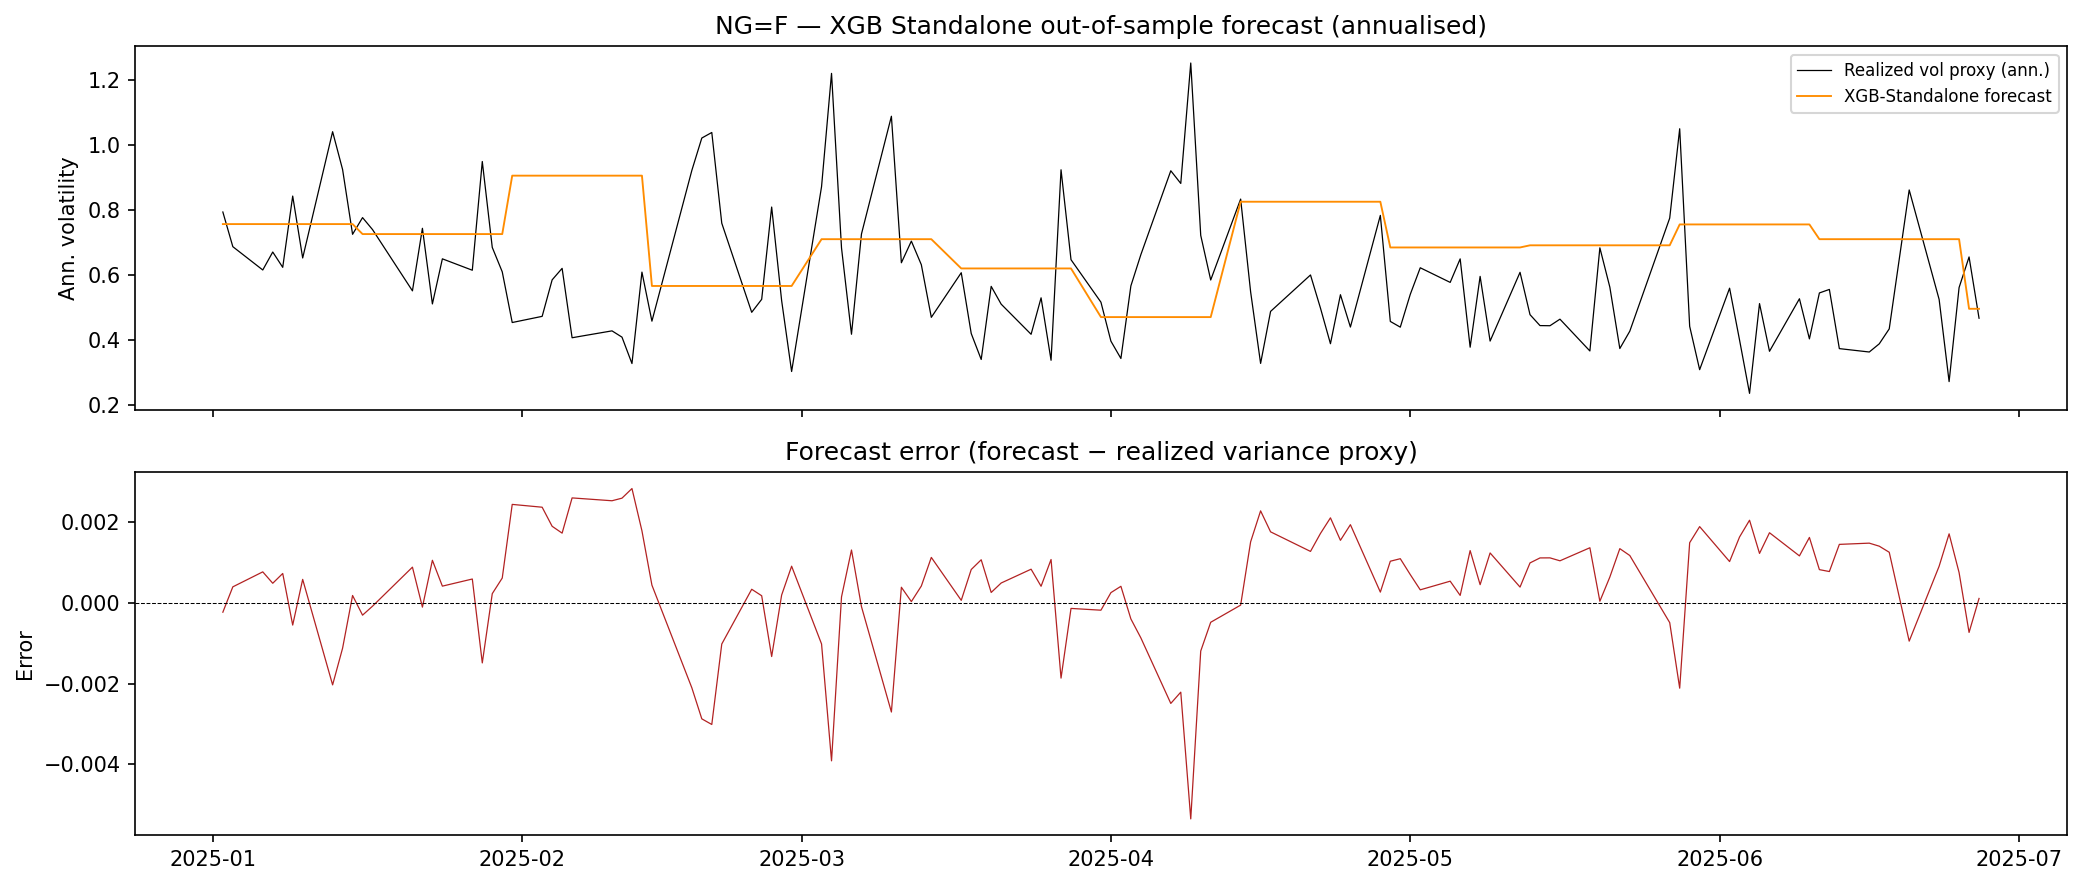

In [22]:
r_xgb = xgb_results["XGB-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_xgb.actuals.index.to_timestamp(), np.sqrt(r_xgb.actuals.values * 252),
             color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_xgb.forecasts.index.to_timestamp(), np.sqrt(r_xgb.forecasts.values * 252),
             color='darkorange', linewidth=0.9, label='XGB-Standalone forecast')
axes[0].set_title(f"{TICKER} — XGB Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_xgb.errors.index.to_timestamp(), r_xgb.errors.values,
             color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()

# 6. Hybrid XGBoost

Two hybrid architectures evaluated for each GARCH base model specified in `HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | XGB predicts variance directly; GARCH one-step forecast h_{t+1\|t} is included as an additional feature alongside lagged returns. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + XGB_residual, where XGB is trained to predict the in-sample GARCH residual (r²_t − h_{t\|t-1}). |

## 6.1 Out-of-sample evaluation

In [23]:
_mode_short = {"features": "feat", "residual": "resid"}

hybrid_eval_specs = [
    (
        partial(XGBHybridModel,
                garch_model_type=gt,
                garch_dist=gd,
                mode=m,
                n_lags=HYBRID_N_LAGS,
                use_returns=HYBRID_USE_RETURNS,
                use_optuna=HYBRID_USE_OPTUNA,
                n_trials=HYBRID_N_TRIALS,
                optuna_n_jobs=HYBRID_OPTUNA_JOBS,
                xgb_params=HYBRID_PARAMS),
        f"XGB-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in HYBRID_SPECS
]

hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    hybrid_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=PARALLEL_JOBS,
)
print(f"\nCompleted {len(hybrid_results)} hybrid model(s).")

Parallel evaluation: 15 models on 10 worker process(es)...
  [XGB-GARCH-GED-feat] done  RMSE=1.3566e-03
  [XGB-GARCH-NORMAL-feat] done  RMSE=1.3536e-03
  [XGB-GJR-GARCH-NORMAL-feat] done  RMSE=1.3873e-03
  [XGB-EGARCH-T-feat] done  RMSE=1.3364e-03
  [XGB-APARCH-NORMAL-feat] done  RMSE=1.3339e-03
  [XGB-GARCH-T-feat] done  RMSE=1.3599e-03
  [XGB-EGARCH-NORMAL-feat] done  RMSE=1.3259e-03
  [XGB-EGARCH-GED-feat] done  RMSE=1.4858e-03
  [XGB-GJR-GARCH-GED-feat] done  RMSE=1.4590e-03
  [XGB-GJR-GARCH-T-feat] done  RMSE=1.4512e-03
  [XGB-APARCH-GED-feat] done  RMSE=1.4013e-03
  [XGB-APARCH-T-feat] done  RMSE=1.3596e-03
  [XGB-FIGARCH-NORMAL-feat] done  RMSE=1.4782e-03
  [XGB-FIGARCH-T-feat] done  RMSE=1.4325e-03
  [XGB-FIGARCH-GED-feat] done  RMSE=1.3402e-03

Completed 15 hybrid model(s).


In [24]:
hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
hybrid_metrics_df

,RMSE,MAE,MSE,QLIKE
XGB-EGARCH-NORMAL-feat,0.001326,0.001091,0.000002,-5.380459
XGB-APARCH-NORMAL-feat,0.001334,0.001129,0.000002,-5.400314
XGB-EGARCH-T-feat,0.001336,0.001126,0.000002,-5.398237
XGB-FIGARCH-GED-feat,0.001340,0.001114,0.000002,-5.402720
XGB-GARCH-NORMAL-feat,0.001354,0.001126,0.000002,-5.404621
XGB-GARCH-GED-feat,0.001357,0.001130,0.000002,-5.398970
XGB-APARCH-T-feat,0.001360,0.001151,0.000002,-5.389770
XGB-GARCH-T-feat,0.001360,0.001156,0.000002,-5.410722
XGB-GJR-GARCH-NORMAL-feat,0.001387,0.001173,0.000002,-5.389207
XGB-APARCH-GED-feat,0.001401,0.001180,0.000002,-5.318886


## 6.2 Feature importance (hybrid models)

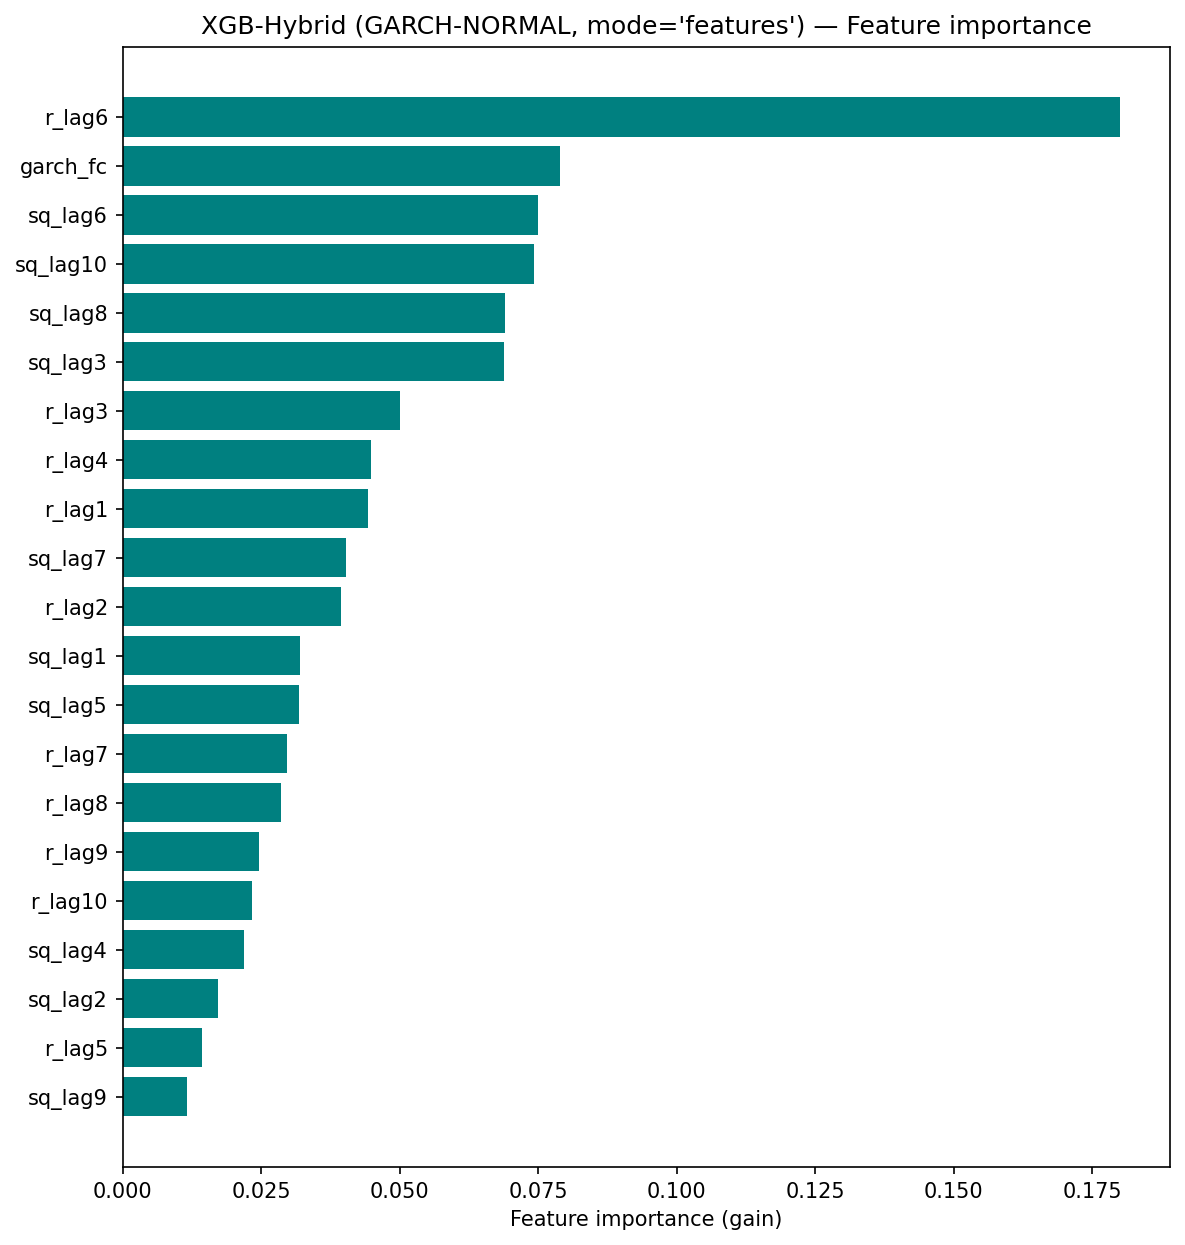

In [25]:
# Fit one representative hybrid model per mode for inspection
# Uses the first spec for each mode found in HYBRID_SPECS
from collections import OrderedDict

viz_specs = OrderedDict()
for gt, gd, m in HYBRID_SPECS:
    if m not in viz_specs:
        viz_specs[m] = (gt, gd)

for mode, (gt, gd) in viz_specs.items():
    h_viz = XGBHybridModel(
        garch_model_type=gt, garch_dist=gd, mode=mode,
        n_lags=HYBRID_N_LAGS, use_returns=HYBRID_USE_RETURNS,
        use_optuna=False, xgb_params=HYBRID_PARAMS,
    )
    h_viz.fit(train_returns)

    feat_names  = h_viz.feature_names()
    importances = h_viz._xgb.feature_importances_
    order       = np.argsort(importances)

    fig, ax = plt.subplots(figsize=(8, max(3, len(feat_names) * 0.4)), dpi=150)
    ax.barh([feat_names[i] for i in order], importances[order], color='teal')
    ax.set_xlabel("Feature importance (gain)")
    ax.set_title(f"XGB-Hybrid ({gt}-{gd.upper()}, mode='{mode}') — Feature importance")
    plt.tight_layout()
    plt.show()

## 6.3 Residual decomposition (residual-correction models)

In [26]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in hybrid_results if name.endswith("-resid")]

# Identify corresponding GARCH standalone result for each residual hybrid
for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. XGB-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['XGB', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

# 7. Standalone LSTM

LSTM trained on a rolling window of `[return, squared_return]` (winsorized, RobustScaler-scaled).
Target: next-step log(squared_return), RobustScaler-scaled, inverse-transformed and exponentiated
back to variance units at forecast time.

> **Retransformation correction.** Trained on log(r²) under MSE, the network estimates E[log r² | X],
> so a plain `exp()` of its output is the conditional *geometric* mean — not the conditional variance
> E[r² | X] that the GARCH and XGB models forecast and that RMSE/QLIKE score. Uncorrected, the LSTM
> forecast came out ≈0.2× the realized level on this data, which QLIKE punishes severely (−2.7 vs
> −6.2) and which pushed every LSTM out of the MCS. `LSTM_RETRANSFORM = "smearing"` applies the
> Duan (1983) smearing factor estimated on the fit residuals; set it to `"none"` to reproduce the
> uncorrected numbers.

## 7.1 Out-of-sample evaluation

In [27]:
lstm_eval_specs = [
    (
        partial(LSTMVolatilityModel,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                retransform=LSTM_RETRANSFORM,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        "LSTM-Standalone",
    )
]

lstm_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_results)} standalone LSTM model(s).")


Parallel evaluation: 1 models on 10 worker process(es)...
  [LSTM-Standalone] done  RMSE=1.3692e-03

Completed 1 standalone LSTM model(s).


In [28]:
lstm_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-Standalone,0.001369,0.001142,0.000002,-5.392192


## 7.2 Forecast vs realized

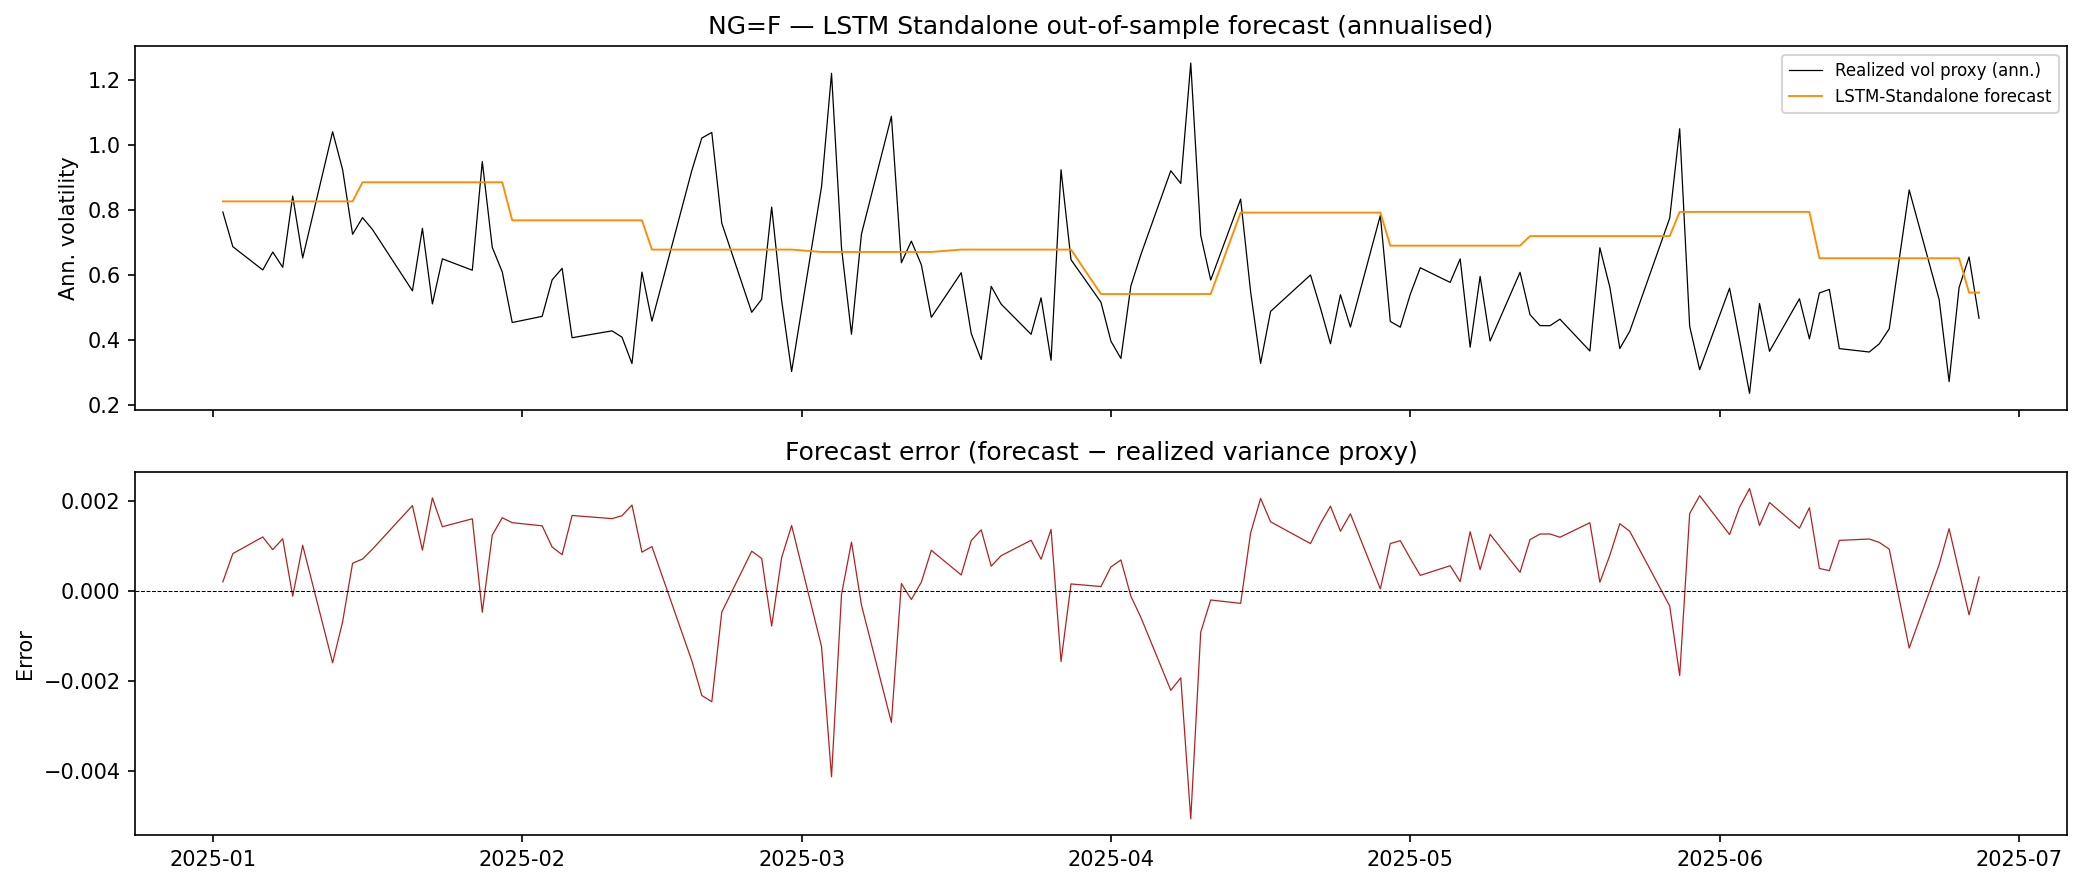

In [29]:
r_lstm = lstm_results["LSTM-Standalone"]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), dpi=150, sharex=True)
axes[0].plot(r_lstm.actuals.index.to_timestamp(), np.sqrt(r_lstm.actuals.values * 252),
              color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
axes[0].plot(r_lstm.forecasts.index.to_timestamp(), np.sqrt(r_lstm.forecasts.values * 252),
              color='darkorange', linewidth=0.9, label='LSTM-Standalone forecast')
axes[0].set_title(f"{TICKER} — LSTM Standalone out-of-sample forecast (annualised)")
axes[0].set_ylabel("Ann. volatility")
axes[0].legend(fontsize=8)
axes[1].plot(r_lstm.errors.index.to_timestamp(), r_lstm.errors.values,
              color='firebrick', linewidth=0.6)
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title("Forecast error (forecast − realized variance proxy)")
axes[1].set_ylabel("Error")
plt.tight_layout()
plt.show()


# 8. Hybrid LSTM

Two hybrid architectures evaluated for each GARCH base model specified in `LSTM_HYBRID_SPECS`:

| Mode | Description |
|------|-------------|
| `features` | LSTM inputs are `[return, squared_return]` plus the GARCH one-step forecast h_{t+1\|t} (log-scaled), broadcast across every timestep of the lookback window. |
| `residual` | **Residual correction**: final forecast = GARCH_forecast + LSTM_residual, where LSTM is trained to predict the GARCH residual (r²_t − h_{t\|t-1}). |

`LSTM_RETRANSFORM` applies to `features` mode only — it shares the standalone model's log(r²) target.
`residual` mode is fit on the level scale (r²_t − h_{t|t-1}, which can be negative) and needs no
correction.

## 8.1 Out-of-sample evaluation

In [30]:
_mode_short = {"features": "feat", "residual": "resid"}

lstm_hybrid_eval_specs = [
    (
        partial(LSTMHybridModel,
                garch_model_type=gt,
                garch_dist=gd,
                mode=m,
                lookback=LSTM_LOOKBACK,
                hidden_size=LSTM_HIDDEN_SIZE,
                num_layers=LSTM_NUM_LAYERS,
                dropout=LSTM_DROPOUT,
                lr=LSTM_LR,
                max_epochs=LSTM_MAX_EPOCHS,
                patience=LSTM_PATIENCE,
                batch_size=LSTM_BATCH_SIZE,
                val_fraction=LSTM_VAL_FRACTION,
                winsor_limits=LSTM_WINSOR_LIMITS,
                retransform=LSTM_RETRANSFORM,
                seed=RANDOM_SEED,
                device=LSTM_DEVICE),
        f"LSTM-{gt}-{gd.upper()}-{_mode_short[m]}",
    )
    for gt, gd, m in LSTM_HYBRID_SPECS
]

lstm_hybrid_results: dict[str, ForecastResult] = evaluator.evaluate_many(
    lstm_hybrid_eval_specs, train_returns, test_returns,
    actuals_series=variance_proxy,
    verbose=True, n_jobs=LSTM_PARALLEL_JOBS,
)
print(f"\nCompleted {len(lstm_hybrid_results)} hybrid LSTM model(s).")


Parallel evaluation: 15 models on 10 worker process(es)...
  [LSTM-GARCH-GED-feat] done  RMSE=1.3088e-03
  [LSTM-GJR-GARCH-NORMAL-feat] done  RMSE=1.3090e-03
  [LSTM-GJR-GARCH-T-feat] done  RMSE=1.3159e-03
  [LSTM-GARCH-T-feat] done  RMSE=1.3094e-03
  [LSTM-EGARCH-T-feat] done  RMSE=1.3009e-03
  [LSTM-GARCH-NORMAL-feat] done  RMSE=1.3089e-03
  [LSTM-GJR-GARCH-GED-feat] done  RMSE=1.3091e-03
  [LSTM-APARCH-NORMAL-feat] done  RMSE=1.2936e-03
  [LSTM-EGARCH-GED-feat] done  RMSE=1.2938e-03
  [LSTM-EGARCH-NORMAL-feat] done  RMSE=1.2970e-03
  [LSTM-APARCH-T-feat] done  RMSE=1.2913e-03
  [LSTM-APARCH-GED-feat] done  RMSE=1.2898e-03
  [LSTM-FIGARCH-NORMAL-feat] done  RMSE=1.2850e-03
  [LSTM-FIGARCH-T-feat] done  RMSE=1.2976e-03
  [LSTM-FIGARCH-GED-feat] done  RMSE=1.2798e-03

Completed 15 hybrid LSTM model(s).


In [31]:
lstm_hybrid_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in lstm_hybrid_results.items()})
    .T
    .sort_values("RMSE")
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
lstm_hybrid_metrics_df


,RMSE,MAE,MSE,QLIKE
LSTM-FIGARCH-GED-feat,0.001280,0.001032,0.000002,-5.418679
LSTM-FIGARCH-NORMAL-feat,0.001285,0.001036,0.000002,-5.417243
LSTM-APARCH-GED-feat,0.001290,0.001042,0.000002,-5.417704
LSTM-APARCH-T-feat,0.001291,0.001044,0.000002,-5.417864
LSTM-APARCH-NORMAL-feat,0.001294,0.001045,0.000002,-5.415985
LSTM-EGARCH-GED-feat,0.001294,0.001040,0.000002,-5.420570
LSTM-EGARCH-NORMAL-feat,0.001297,0.001043,0.000002,-5.419173
LSTM-FIGARCH-T-feat,0.001298,0.001050,0.000002,-5.415261
LSTM-EGARCH-T-feat,0.001301,0.001049,0.000002,-5.417605
LSTM-GARCH-GED-feat,0.001309,0.001062,0.000002,-5.410910


## 8.2 Residual decomposition (residual-correction models)

In [32]:
# For each residual-mode hybrid in the results, plot the decomposition:
#   realized variance, GARCH standalone forecast, and final hybrid forecast

resid_names = [name for name in lstm_hybrid_results if name.endswith("-resid")]

for h_name in resid_names:
    # derive base GARCH name from hybrid name, e.g. LSTM-GARCH-NORMAL-resid → GARCH-NORMAL
    parts      = h_name.split("-")  # ['LSTM', 'GARCH', 'NORMAL', 'resid']
    garch_name = "-".join(parts[1:-1])  # 'GARCH-NORMAL'

    r_h  = lstm_hybrid_results[h_name]
    r_g  = garch_results.get(garch_name)

    fig, ax = plt.subplots(figsize=(14, 4), dpi=150)
    ax.plot(r_h.actuals.index.to_timestamp(), np.sqrt(r_h.actuals.values * 252),
            color='black', linewidth=0.6, label='Realized vol proxy (ann.)')
    if r_g is not None:
        ax.plot(r_g.forecasts.index.to_timestamp(), np.sqrt(r_g.forecasts.values * 252),
                color='steelblue', linewidth=0.8, linestyle='--', label=f'{garch_name} (base GARCH)', alpha=0.8)
    ax.plot(r_h.forecasts.index.to_timestamp(), np.sqrt(r_h.forecasts.values * 252),
            color='darkorchid', linewidth=0.9, label=f'{h_name} (hybrid final)')
    ax.set_title(f"{TICKER} — Residual correction: {h_name}")
    ax.set_ylabel("Ann. volatility")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


# 9. Joint Evaluation — All Models

Combined metrics table and forecast overlay across all model groups.

> **Note on QLIKE.** The reported QLIKE is `mean(log h_t + proxy_t / h_t)`, which equals the Patton (2011) robust QLIKE up to a model-independent additive constant. Only *differences* and the *ordering* across models are interpretable — the absolute level (e.g. −6.6) carries no meaning on its own. DM and MCS (which use loss differences) are unaffected by the constant.

> **Note on RMSE across proxies.** RMSE magnitudes are not comparable between different `VARIANCE_PROXY` settings (the target variable differs). Compare RMSE only *within* a single proxy; across proxies, rely on the ranking / QLIKE.

In [33]:
all_results: dict[str, ForecastResult] = {
    **garch_results,
    **xgb_results,
    **hybrid_results,
    **lstm_results,
    **lstm_hybrid_results,
}

# Guard the merge. A group that was never run (or was lost to a kernel restart)
# would silently vanish from every joint table, the DM matrix and the MCS below,
# and a name reused across two groups would be overwritten without any error.
# Both failure modes look identical from the outside: "my models aren't there".
_sources = {
    "garch_results":       garch_results,
    "xgb_results":         xgb_results,
    "hybrid_results":      hybrid_results,
    "lstm_results":        lstm_results,
    "lstm_hybrid_results": lstm_hybrid_results,
}
_missing = [k for k, v in _sources.items() if not v]
if _missing:
    raise RuntimeError(f"Model group(s) empty: {_missing} — re-run those sections first.")
_n_evaluated = sum(len(v) for v in _sources.values())
if len(all_results) != _n_evaluated:
    raise RuntimeError(
        f"Duplicate model names: {_n_evaluated} models were evaluated but only "
        f"{len(all_results)} unique names survived the merge."
    )


def _group(name: str) -> str:
    if name.startswith("XGB-") and "-feat" in name:
        return "XGB Hybrid (features)"
    if name.startswith("XGB-") and "-resid" in name:
        return "XGB Hybrid (residual)"
    if name.startswith("XGB-"):
        return "Standalone XGB"
    if name.startswith("LSTM-") and "-feat" in name:
        return "LSTM Hybrid (features)"
    if name.startswith("LSTM-") and "-resid" in name:
        return "LSTM Hybrid (residual)"
    if name.startswith("LSTM-"):
        return "Standalone LSTM"
    return "GARCH"


all_metrics_df = (
    pd.DataFrame({name: r.metrics() for name, r in all_results.items()})
    .T
    [["RMSE", "MAE", "MSE", "QLIKE"]]
)
all_metrics_df.insert(0, "Group", all_metrics_df.index.map(_group))
all_metrics_df = all_metrics_df.sort_values(["Group", "RMSE"])

print(f"{len(all_metrics_df)} models across {all_metrics_df['Group'].nunique()} groups:")
print(all_metrics_df["Group"].value_counts().to_string(), "\n")

# Best model per group, so no group can be hidden by the global ranking.
print("Best model per group (lowest QLIKE — the loss DM and MCS use):")
print(
    all_metrics_df.sort_values("QLIKE").groupby("Group", sort=False).head(1)
    .to_string(float_format=lambda v: f"{v:.6e}"),
    "\n",
)

# Full table — every model, every group. This cell used to display only
# .head(10) of the global RMSE ranking, which silently dropped whole groups
# (no LSTM model ever ranked top-10 on RMSE, so the "all models" table showed
# none of them).
all_metrics_df.sort_values("QLIKE")

47 models across 5 groups:
Group
GARCH                     15
LSTM Hybrid (features)    15
XGB Hybrid (features)     15
Standalone LSTM            1
Standalone XGB             1 

Best model per group (lowest QLIKE — the loss DM and MCS use):
                                       Group         RMSE          MAE          MSE         QLIKE
LSTM-EGARCH-GED-feat  LSTM Hybrid (features) 1.293789e-03 1.040319e-03 1.673889e-06 -5.420570e+00
XGB-GARCH-T-feat       XGB Hybrid (features) 1.359852e-03 1.155857e-03 1.849196e-06 -5.410722e+00
APARCH-T                               GARCH 1.428071e-03 1.170238e-03 2.039385e-06 -5.402539e+00
LSTM-Standalone              Standalone LSTM 1.369223e-03 1.142457e-03 1.874773e-06 -5.392192e+00
XGB-Standalone                Standalone XGB 1.450317e-03 1.148584e-03 2.103418e-06 -5.350662e+00 



,Group,RMSE,MAE,MSE,QLIKE
LSTM-EGARCH-GED-feat,LSTM Hybrid (features),0.001294,0.001040,0.000002,-5.420570
LSTM-EGARCH-NORMAL-feat,LSTM Hybrid (features),0.001297,0.001043,0.000002,-5.419173
LSTM-FIGARCH-GED-feat,LSTM Hybrid (features),0.001280,0.001032,0.000002,-5.418679
LSTM-APARCH-T-feat,LSTM Hybrid (features),0.001291,0.001044,0.000002,-5.417864
LSTM-APARCH-GED-feat,LSTM Hybrid (features),0.001290,0.001042,0.000002,-5.417704
LSTM-EGARCH-T-feat,LSTM Hybrid (features),0.001301,0.001049,0.000002,-5.417605
LSTM-FIGARCH-NORMAL-feat,LSTM Hybrid (features),0.001285,0.001036,0.000002,-5.417243
LSTM-APARCH-NORMAL-feat,LSTM Hybrid (features),0.001294,0.001045,0.000002,-5.415985
LSTM-FIGARCH-T-feat,LSTM Hybrid (features),0.001298,0.001050,0.000002,-5.415261
LSTM-GJR-GARCH-NORMAL-feat,LSTM Hybrid (features),0.001309,0.001061,0.000002,-5.411036


In [34]:
# Forecast-sanity screen across ALL model groups. Two independent failures are
# flagged:
#   degenerate — forecasts numerically broken (variance collapsing toward 0 blows
#                up QLIKE; exploding upward blows up RMSE). One such model
#                poisons the joint metrics, the DM matrix and the MCS for
#                everyone. Observed with EGARCH on short (~500-obs) windows.
#   biased     — forecasts finite and smooth but at the wrong LEVEL, i.e.
#                mean(forecast)/mean(proxy) off by more than 2x. Every model here
#                forecasts the same E[r^2], so this ratio should sit near 1. This
#                catches transform errors (e.g. exponentiating a log-scale target
#                without a retransformation correction), which the degeneracy
#                screen alone passes as clean while QLIKE and the MCS reject the
#                model outright.
diag_df = forecast_diagnostics(all_results)  # warns per affected model

_bad = diag_df.index[diag_df["degenerate"]].tolist()
if _bad:
    print(f"\u26a0 DEGENERATE models — exclude before trusting DM/MCS: {_bad}\n")
else:
    print("\u2713 No degenerate forecasts — metrics are trustworthy.\n")

_biased = diag_df.index[diag_df["biased"] & ~diag_df["degenerate"]].tolist()
if _biased:
    print(f"\u26a0 MIS-SCALED models (mean forecast off by >2x — check the model, "
          f"not the tests): {_biased}\n")
else:
    print("\u2713 All forecasts on the right scale (mean forecast within 2x of the proxy).\n")

diag_df[["n", "min_forecast", "max_forecast", "n_extreme_low",
         "n_extreme_high", "bias_ratio", "RMSE", "QLIKE",
         "degenerate", "biased"]].style.map(
    lambda v: "background-color: #ffcdd2; font-weight: bold" if v is True else "",
    subset=["degenerate", "biased"],
).format({"min_forecast": "{:.2e}", "max_forecast": "{:.2e}", "bias_ratio": "{:.2f}",
          "RMSE": "{:.3e}", "QLIKE": "{:.3e}"})

✓ No degenerate forecasts — metrics are trustworthy.

✓ All forecasts on the right scale (mean forecast within 2x of the proxy).



,n,min_forecast,max_forecast,n_extreme_low,n_extreme_high,bias_ratio,RMSE,QLIKE,degenerate,biased
XGB-APARCH-GED-feat,122,6.31e-04,3.13e-03,0,0,1.26,1.401e-03,-5.319e+00,False,False
XGB-Standalone,122,8.84e-04,3.27e-03,0,0,1.28,1.450e-03,-5.351e+00,False,False
XGB-FIGARCH-NORMAL-feat,122,1.14e-03,3.08e-03,0,0,1.38,1.478e-03,-5.370e+00,False,False
XGB-EGARCH-GED-feat,122,1.24e-03,3.35e-03,0,0,1.42,1.486e-03,-5.370e+00,False,False
FIGARCH-NORMAL,122,1.36e-03,4.17e-03,0,0,1.57,1.600e-03,-5.370e+00,False,False
GJR-GARCH-NORMAL,122,1.35e-03,4.63e-03,0,0,1.55,1.651e-03,-5.372e+00,False,False
FIGARCH-GED,122,1.37e-03,3.91e-03,0,0,1.56,1.561e-03,-5.374e+00,False,False
EGARCH-NORMAL,122,1.32e-03,4.20e-03,0,0,1.55,1.600e-03,-5.374e+00,False,False
GARCH-NORMAL,122,1.35e-03,4.46e-03,0,0,1.55,1.622e-03,-5.374e+00,False,False
APARCH-NORMAL,122,1.32e-03,4.44e-03,0,0,1.52,1.606e-03,-5.378e+00,False,False


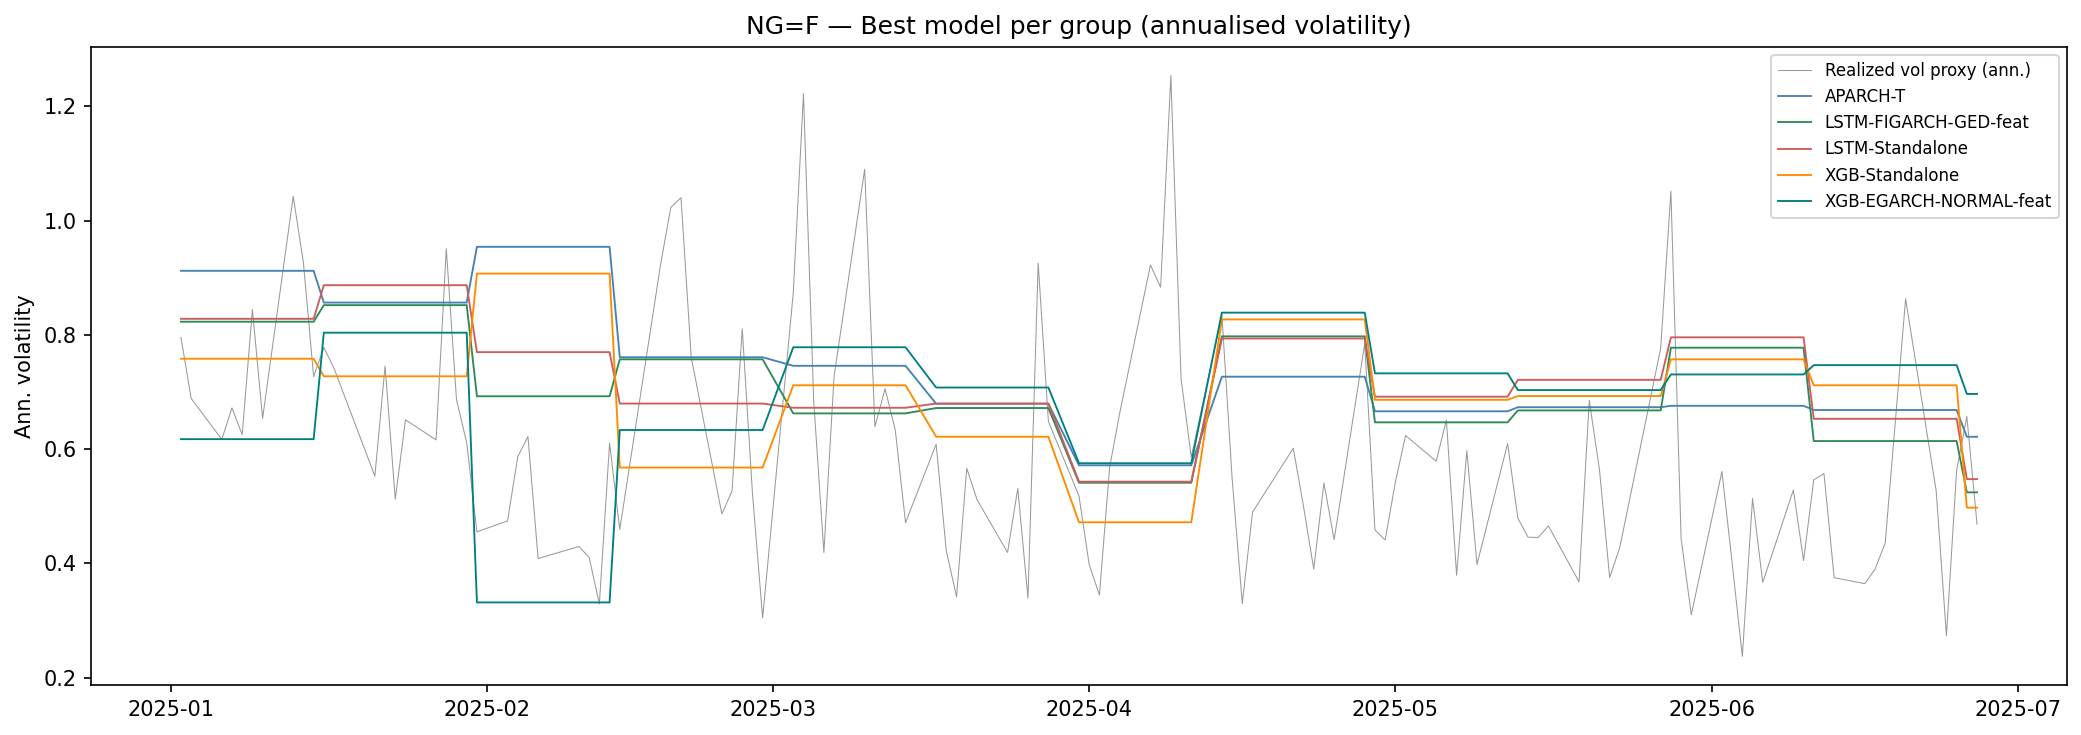

In [35]:
# Best model per group + realized variance overlay
groups = all_metrics_df["Group"].unique()
palette = {
    "GARCH": "steelblue",
    "Standalone XGB": "darkorange",
    "XGB Hybrid (features)": "teal",
    "XGB Hybrid (residual)": "darkorchid",
    "Standalone LSTM": "indianred",
    "LSTM Hybrid (features)": "seagreen",
    "LSTM Hybrid (residual)": "goldenrod",
}

fig, ax = plt.subplots(figsize=(14, 5), dpi=150)
# realized vol proxy (use any result's actuals — they are identical)
ref = next(iter(all_results.values()))
ax.plot(ref.actuals.index.to_timestamp(), np.sqrt(ref.actuals.values * 252),
        color='black', linewidth=0.5, alpha=0.4, label='Realized vol proxy (ann.)')

for grp in groups:
    best_name = all_metrics_df[all_metrics_df["Group"] == grp].sort_values("RMSE").index[0]
    r = all_results[best_name]
    ax.plot(r.forecasts.index.to_timestamp(), np.sqrt(r.forecasts.values * 252),
            linewidth=0.9, label=f"{best_name}", color=palette.get(grp, 'gray'))

ax.set_title(f"{TICKER} — Best model per group (annualised volatility)")
ax.set_ylabel("Ann. volatility")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


# 10. Statistical Tests

All model groups evaluated jointly.

## 10.1 Diebold-Mariano Test (HLN correction)

Pairwise test of equal predictive accuracy (Harvey, Leybourne & Newbold 1997).  
H₀: models *i* and *j* have equal expected loss.  
Negative MDM statistic → row model has lower loss than column model.  
p-values two-sided from *t*(T−1).

In [36]:
dm_stat_df, dm_pval_df = dm_matrix(all_results, h=N_AHEAD, loss=TEST_LOSS)

print("MDM statistics (upper triangle):")
dm_stat_df.round(3)

MDM statistics (upper triangle):


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,...,LSTM-GJR-GARCH-GED-feat,LSTM-EGARCH-NORMAL-feat,LSTM-EGARCH-T-feat,LSTM-EGARCH-GED-feat,LSTM-APARCH-NORMAL-feat,LSTM-APARCH-T-feat,LSTM-APARCH-GED-feat,LSTM-FIGARCH-NORMAL-feat,LSTM-FIGARCH-T-feat,LSTM-FIGARCH-GED-feat
GARCH-NORMAL,NaN,8.327,8.049,-1.914,6.405,7.821,-0.003,4.269,3.090,3.983,...,2.169,2.411,2.326,2.482,2.333,2.377,2.380,2.373,2.171,2.458
GARCH-T,NaN,NaN,-8.323,-6.981,1.781,-8.582,-4.661,0.804,-1.477,-7.236,...,1.332,1.676,1.586,1.754,1.562,1.630,1.629,1.618,1.435,1.707
GARCH-GED,NaN,NaN,NaN,-6.212,4.666,2.022,-3.115,2.333,0.422,-5.979,...,1.671,1.973,1.883,2.048,1.874,1.931,1.932,1.924,1.731,2.012
GJR-GARCH-NORMAL,NaN,NaN,NaN,NaN,5.508,6.057,0.459,3.946,2.953,4.197,...,2.186,2.414,2.329,2.482,2.341,2.380,2.384,2.380,2.183,2.461
GJR-GARCH-T,NaN,NaN,NaN,NaN,NaN,-4.781,-5.521,0.218,-2.651,-5.472,...,1.263,1.640,1.546,1.722,1.514,1.591,1.589,1.574,1.384,1.669
GJR-GARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,-3.215,2.328,0.372,-5.924,...,1.667,1.971,1.881,2.046,1.871,1.929,1.930,1.921,1.727,2.009
EGARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.303,7.971,1.281,...,2.298,2.549,2.476,2.626,2.465,2.520,2.518,2.504,2.312,2.594
EGARCH-T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.304,-3.490,...,1.240,1.638,1.557,1.725,1.502,1.593,1.584,1.558,1.388,1.657
EGARCH-GED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.141,...,1.690,2.023,1.945,2.105,1.911,1.985,1.980,1.960,1.779,2.055
APARCH-NORMAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.982,2.240,2.151,2.310,2.156,2.202,2.205,2.202,2.004,2.287


In [37]:
print(f"DM p-values — highlighted: p < {DM_ALPHA}")
dm_pval_df.round(4).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold"
    if (not pd.isna(v) and v < DM_ALPHA) else "",
)

DM p-values — highlighted: p < 0.05


,GARCH-NORMAL,GARCH-T,GARCH-GED,GJR-GARCH-NORMAL,GJR-GARCH-T,GJR-GARCH-GED,EGARCH-NORMAL,EGARCH-T,EGARCH-GED,APARCH-NORMAL,APARCH-T,APARCH-GED,FIGARCH-NORMAL,FIGARCH-T,FIGARCH-GED,XGB-Standalone,XGB-GARCH-NORMAL-feat,XGB-GARCH-T-feat,XGB-GARCH-GED-feat,XGB-GJR-GARCH-NORMAL-feat,XGB-GJR-GARCH-T-feat,XGB-GJR-GARCH-GED-feat,XGB-EGARCH-NORMAL-feat,XGB-EGARCH-T-feat,XGB-EGARCH-GED-feat,XGB-APARCH-NORMAL-feat,XGB-APARCH-T-feat,XGB-APARCH-GED-feat,XGB-FIGARCH-NORMAL-feat,XGB-FIGARCH-T-feat,XGB-FIGARCH-GED-feat,LSTM-Standalone,LSTM-GARCH-NORMAL-feat,LSTM-GARCH-T-feat,LSTM-GARCH-GED-feat,LSTM-GJR-GARCH-NORMAL-feat,LSTM-GJR-GARCH-T-feat,LSTM-GJR-GARCH-GED-feat,LSTM-EGARCH-NORMAL-feat,LSTM-EGARCH-T-feat,LSTM-EGARCH-GED-feat,LSTM-APARCH-NORMAL-feat,LSTM-APARCH-T-feat,LSTM-APARCH-GED-feat,LSTM-FIGARCH-NORMAL-feat,LSTM-FIGARCH-T-feat,LSTM-FIGARCH-GED-feat
GARCH-NORMAL,nan,0.000000,0.000000,0.058000,0.000000,0.000000,0.997500,0.000000,0.002500,0.000100,0.000000,0.000000,0.084600,0.038700,0.901200,0.378600,0.098300,0.023700,0.081000,0.312900,0.458400,0.281200,0.806200,0.178200,0.733500,0.124800,0.255900,0.140600,0.780200,0.115700,0.027600,0.272400,0.033400,0.029700,0.031300,0.031100,0.039400,0.032100,0.017400,0.021700,0.014400,0.021300,0.019000,0.018900,0.019200,0.031900,0.015400
GARCH-T,nan,nan,0.000000,0.000000,0.077400,0.000000,0.000000,0.423200,0.142200,0.000000,0.000400,0.232400,0.000000,0.256400,0.000000,0.130700,0.388600,0.165300,0.482700,0.969000,0.403500,0.830800,0.714700,0.615300,0.079800,0.507400,0.998800,0.054000,0.155500,0.500000,0.268800,0.873900,0.189400,0.177300,0.182100,0.180500,0.224400,0.185300,0.096200,0.115500,0.082000,0.120800,0.105700,0.105900,0.108400,0.153800,0.090300
GARCH-GED,nan,nan,nan,0.000000,0.000000,0.045400,0.002300,0.021300,0.673400,0.000000,0.000000,0.000200,0.000000,0.907100,0.007300,0.202100,0.238300,0.083300,0.259400,0.704300,0.837600,0.577700,0.896900,0.403400,0.228500,0.310700,0.649100,0.079300,0.328200,0.299500,0.117100,0.593500,0.100200,0.091900,0.095400,0.094600,0.118900,0.097300,0.050800,0.062100,0.042800,0.063300,0.055800,0.055700,0.056700,0.086100,0.046500
GJR-GARCH-NORMAL,nan,nan,nan,nan,0.000000,0.000000,0.647400,0.000100,0.003800,0.000100,0.000000,0.000000,0.435300,0.031600,0.771600,0.420300,0.091800,0.022900,0.072000,0.275600,0.387000,0.256200,0.759600,0.164500,0.850600,0.114000,0.225900,0.158100,0.874200,0.106200,0.025500,0.249000,0.032000,0.028500,0.030000,0.029800,0.037400,0.030700,0.017300,0.021500,0.014400,0.020900,0.018900,0.018700,0.018900,0.030900,0.015300
GJR-GARCH-T,nan,nan,nan,nan,nan,0.000000,0.000000,0.827700,0.009100,0.000000,0.000000,0.910700,0.000000,0.087700,0.000000,0.103400,0.440000,0.189700,0.574900,0.836200,0.258700,0.931900,0.643500,0.696600,0.040700,0.581900,0.856000,0.043500,0.101800,0.573800,0.325500,0.988300,0.213400,0.199800,0.205200,0.203400,0.255100,0.208900,0.103700,0.124600,0.087600,0.132500,0.114200,0.114700,0.118200,0.168900,0.097700
GJR-GARCH-GED,nan,nan,nan,nan,nan,nan,0.001700,0.021600,0.710400,0.000000,0.000000,0.000100,0.000000,0.936900,0.006000,0.198800,0.240800,0.084300,0.263200,0.713000,0.822300,0.583700,0.891100,0.407900,0.220600,0.314300,0.657700,0.078100,0.320500,0.302900,0.118600,0.599900,0.101000,0.092700,0.096200,0.095300,0.120000,0.098100,0.051000,0.062400,0.043000,0.063700,0.056100,0.056000,0.057000,0.086700,0.046700
EGARCH-NORMAL,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000000,0.202600,0.000000,0.000000,0.217800,0.026100,0.909000,0.357600,0.090800,0.021600,0.076700,0.310200,0.460900,0.261100,0.799500,0.154400,0.701200,0.112100,0.212700,0.134500,0.779300,0.092300,0.020600,0.234000,0.024500,0.021300,0.022700,0.022700,0.029000,0.023300,0.012000,0.014700,0.009800,0.015100,0.013000,0.013100,0.013600,0.022500,0.010600
EGARCH-T,nan,nan,nan,nan,nan,nan,nan,nan,0.000000,0.000700,0.000300,0.792400,0.000000,0.049100,0.000000,0.099100,0.466900,0.202300,0.626800,0.810700,0.271700,0.960900,0.619500,0.713300,0.025700,0.613100,0.815200,0.040900,0.109500,0.59660

### 10.1.1 DM within-group vs between-group split

With 29 models there are 406 pairwise DM tests. Two effects inflate the raw count of significant pairs, so it should not be read at face value:

1. **Multiplicity.** ~20 pairs would be significant at 5% by chance alone, with no family-wise correction (that is what the MCS provides).
2. **(Near-)nesting.** Within the GARCH group, models differing only in the error distribution (e.g. GARCH-NORMAL vs GARCH-T, where Normal is the limiting case of the Student-t) are nearly nested — the loss-differential variance is near-degenerate under H₀, which inflates the DM statistic and makes the standard test oversized (Clark-McCracken; Giacomini-White 2006). A similar caveat applies to hybrid models sharing the same GARCH core.

The split below uses the model **groups** (GARCH / Standalone XGB / XGB Hybrid features / XGB Hybrid residual / Standalone LSTM / LSTM Hybrid features / LSTM Hybrid residual):

- **Between-group** pairs are the core research comparison — *do the ML and hybrid models forecast differently from the GARCH baseline (and from each other)?* These are properly non-nested and the most meaningful.
- **Within-group** pairs (especially inside the GARCH group) carry the nesting/oversizing caveat and should be interpreted with caution.

In [38]:
# Partition the 406 DM pairs by model GROUP (GARCH / XGB / LSTM / hybrids) via _group.
split = dm_family_split(dm_pval_df, alpha=DM_ALPHA, family_of=_group)

total_sig   = split["within"]["n_significant"] + split["between"]["n_significant"]
total_pairs = split["within"]["n_total"] + split["between"]["n_total"]
print(f"DM significant pairs ({TEST_LOSS} loss, p < {DM_ALPHA}): "
      f"{total_sig} / {total_pairs} total\n")

summary_split = pd.DataFrame({
    "n_significant": [split["within"]["n_significant"], split["between"]["n_significant"]],
    "n_total":       [split["within"]["n_total"],       split["between"]["n_total"]],
    "rejection_rate":[split["within"]["rate"],          split["between"]["rate"]],
}, index=["within-group", "between-group (research comparison)"])
print(summary_split.to_string(formatters={"rejection_rate": "{:.1%}".format}))

# Most-rejected models among between-group pairs — surfaces which models are
# genuinely distinguishable across the GARCH / XGB / LSTM / hybrid boundaries.
from collections import Counter
node = Counter()
for a, b, p in split["between"]["pairs"]:
    if p < DM_ALPHA:
        node[a] += 1
        node[b] += 1
print("\nMost frequently rejected models (between-group pairs):")
for name, cnt in node.most_common(8):
    print(f"  {name:<24} [{_group(name):<18}] in {cnt} significant between-group pairs")

DM significant pairs (qlike loss, p < 0.05): 408 / 1081 total

                                     n_significant  n_total rejection_rate
within-group                                   166      315          52.7%
between-group (research comparison)            242      766          31.6%

Most frequently rejected models (between-group pairs):
  XGB-Standalone           [Standalone XGB    ] in 25 significant between-group pairs
  XGB-APARCH-GED-feat      [XGB Hybrid (features)] in 20 significant between-group pairs
  LSTM-EGARCH-GED-feat     [LSTM Hybrid (features)] in 19 significant between-group pairs
  XGB-EGARCH-GED-feat      [XGB Hybrid (features)] in 19 significant between-group pairs
  FIGARCH-NORMAL           [GARCH             ] in 19 significant between-group pairs
  LSTM-FIGARCH-GED-feat    [LSTM Hybrid (features)] in 18 significant between-group pairs
  LSTM-Standalone          [Standalone LSTM   ] in 17 significant between-group pairs
  FIGARCH-GED              [GARCH       

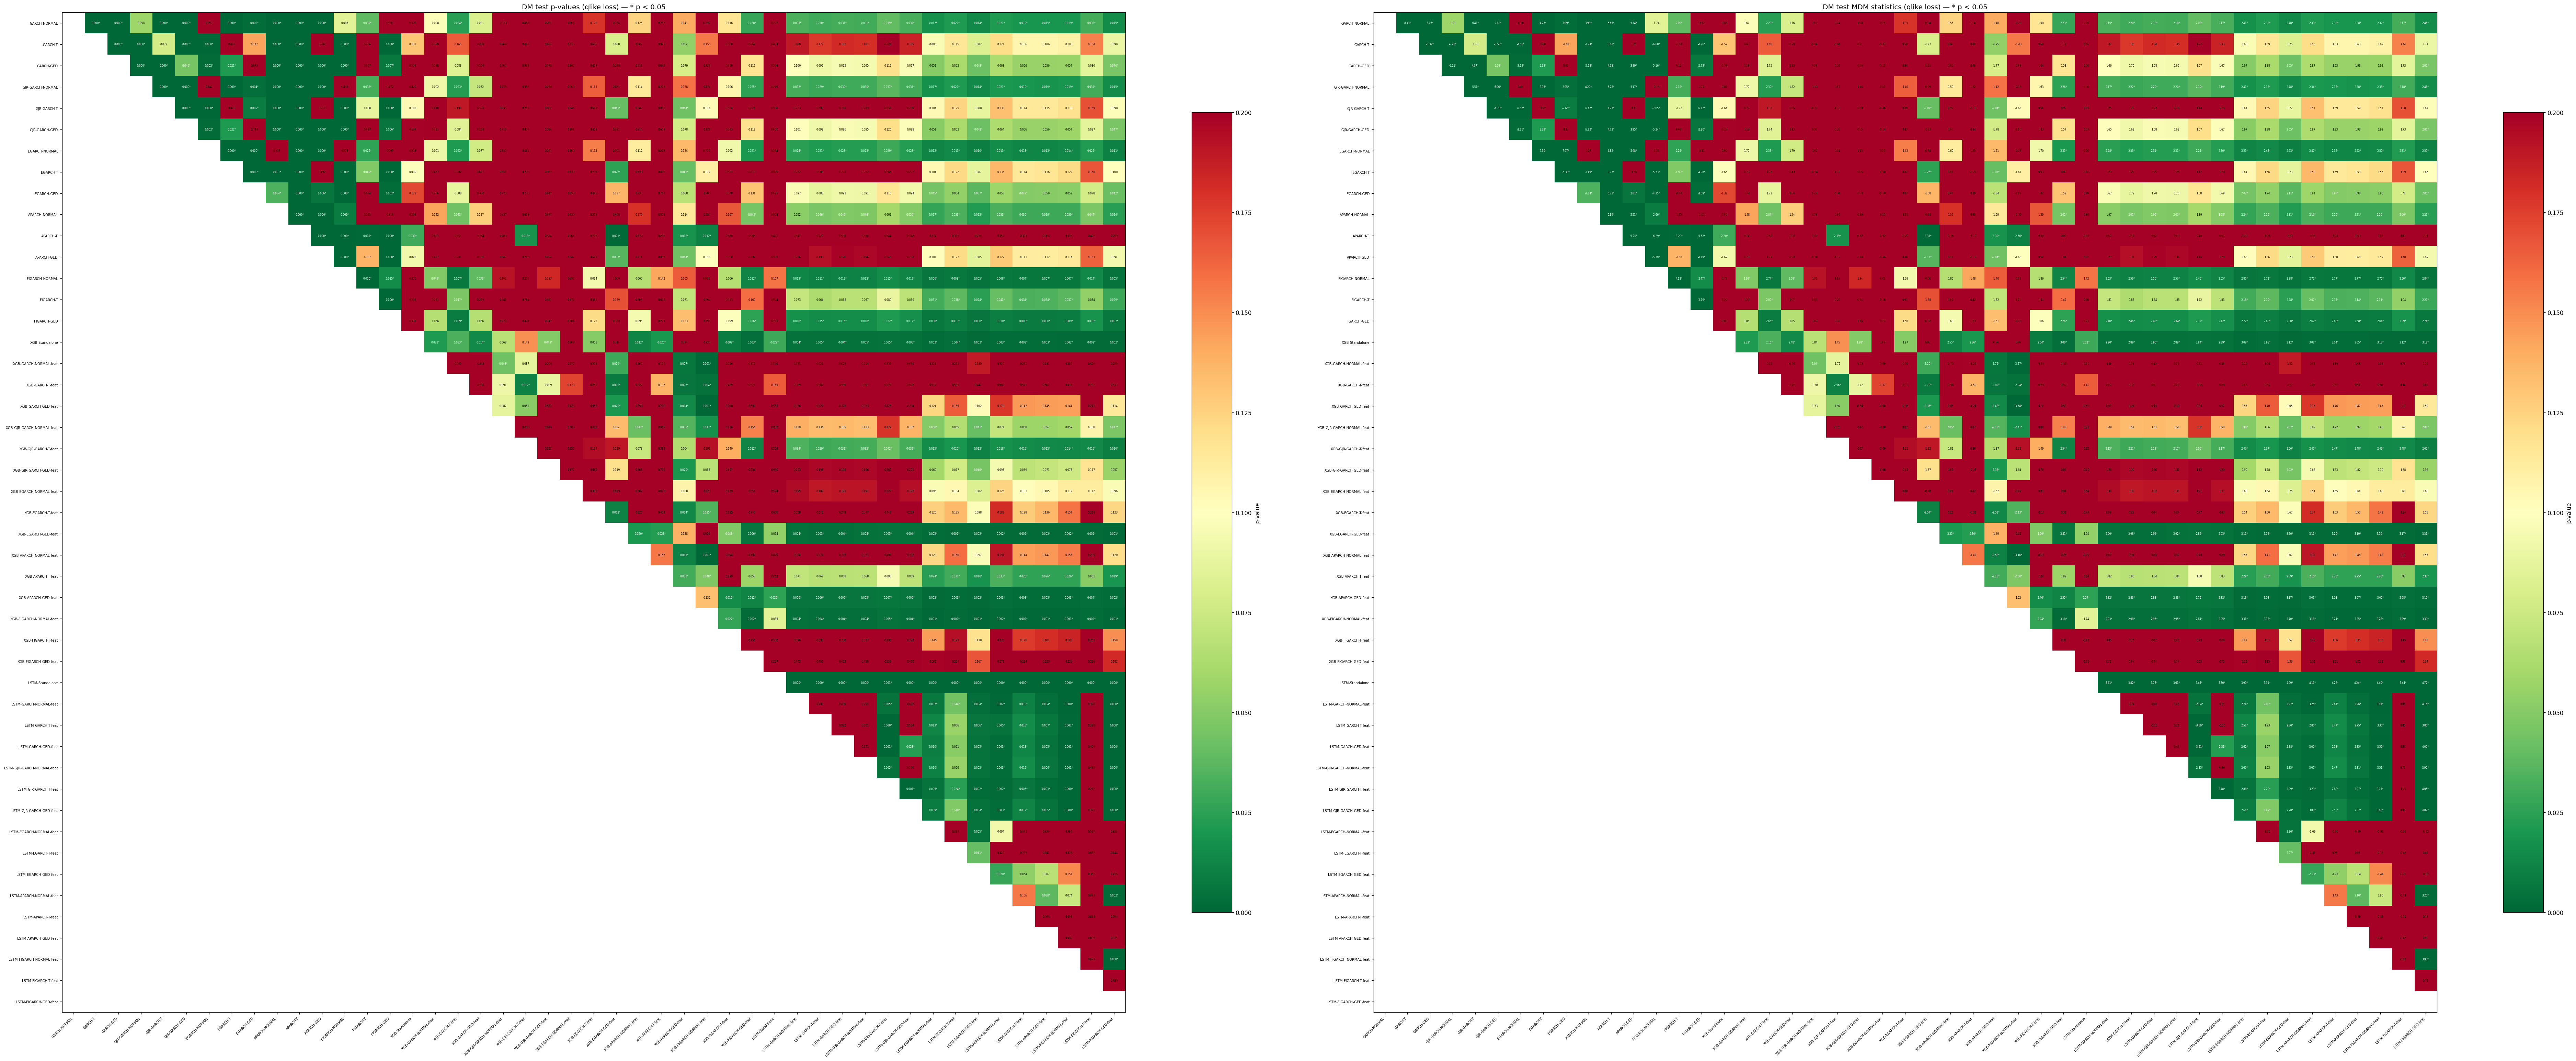

In [39]:
names  = list(all_results.keys())
n_mods = len(names)
pvals  = dm_pval_df.values.astype(float)
stats  = dm_stat_df.values.astype(float)

mask       = np.tril(np.ones_like(pvals, dtype=bool))
pvals_plot = np.where(mask, np.nan, pvals)
stats_plot = np.where(mask, np.nan, stats)

fig, axes = plt.subplots(1, 2, figsize=(max(10, n_mods * 0.7) * 2, max(7, n_mods * 0.55)), dpi=120)

for ax, data, title_suffix, fmt in zip(
    axes,
    [pvals_plot, stats_plot],
    ["p-values", "MDM statistics"],
    ["{:.3f}", "{:.2f}"],
):
    im = ax.imshow(pvals_plot, cmap="RdYlGn_r", vmin=0, vmax=0.20, aspect="auto")
    plt.colorbar(im, ax=ax, label="p-value", shrink=0.8)
    ax.set_xticks(range(n_mods))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6)
    ax.set_yticks(range(n_mods))
    ax.set_yticklabels(names, fontsize=6)
    ax.set_title(f"DM test {title_suffix} ({TEST_LOSS} loss) — * p < {DM_ALPHA}")
    for i in range(n_mods):
        for j in range(i + 1, n_mods):
            val = data[i, j]
            p   = pvals_plot[i, j]
            if not np.isnan(val):
                sig = "*" if (not np.isnan(p) and p < DM_ALPHA) else ""
                ax.text(j, i, fmt.format(val) + sig,
                        ha="center", va="center", fontsize=4.5,
                        color="white" if (not np.isnan(p) and p < 0.05) else "black")

plt.tight_layout()
plt.show()

## 10.2 Model Confidence Set (MCS)

Hansen, Lunde & Nason (2011). Sequential elimination of the worst model until H₀ of equal
predictive accuracy cannot be rejected. Inference via stationary bootstrap (Politis & Romano 1994).

Models with `mcs_pvalue > MCS_ALPHA` belong to the (1 − MCS_ALPHA) MCS.

In [40]:
mcs_result = mcs(
    all_results,
    loss=TEST_LOSS,
    alpha=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)
print(mcs_result)
print()

# NOTE: this procedure stops at the first non-rejection (Hansen et al. 2011),
# so surviving models share the placeholder 1.0 — NOT a real bootstrap p-value.
# mark_early_stop=True shows those as "—" (early_stop=True). For graded within-set
# p-values that rank the survivors, see the arch.bootstrap.MCS cell below.
mcs_result.summary(mark_early_stop=True).style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["in_mcs"],
).format({"mcs_pvalue": "{:.4f}"}, na_rep="—")

MCSResult(alpha=0.05, loss='qlike', n_included=47, models=['GARCH-NORMAL', 'GARCH-T', 'GARCH-GED', 'GJR-GARCH-NORMAL', 'GJR-GARCH-T', 'GJR-GARCH-GED', 'EGARCH-NORMAL', 'EGARCH-T', 'EGARCH-GED', 'APARCH-NORMAL', 'APARCH-T', 'APARCH-GED', 'FIGARCH-NORMAL', 'FIGARCH-T', 'FIGARCH-GED', 'XGB-Standalone', 'XGB-GARCH-NORMAL-feat', 'XGB-GARCH-T-feat', 'XGB-GARCH-GED-feat', 'XGB-GJR-GARCH-NORMAL-feat', 'XGB-GJR-GARCH-T-feat', 'XGB-GJR-GARCH-GED-feat', 'XGB-EGARCH-NORMAL-feat', 'XGB-EGARCH-T-feat', 'XGB-EGARCH-GED-feat', 'XGB-APARCH-NORMAL-feat', 'XGB-APARCH-T-feat', 'XGB-APARCH-GED-feat', 'XGB-FIGARCH-NORMAL-feat', 'XGB-FIGARCH-T-feat', 'XGB-FIGARCH-GED-feat', 'LSTM-Standalone', 'LSTM-GARCH-NORMAL-feat', 'LSTM-GARCH-T-feat', 'LSTM-GARCH-GED-feat', 'LSTM-GJR-GARCH-NORMAL-feat', 'LSTM-GJR-GARCH-T-feat', 'LSTM-GJR-GARCH-GED-feat', 'LSTM-EGARCH-NORMAL-feat', 'LSTM-EGARCH-T-feat', 'LSTM-EGARCH-GED-feat', 'LSTM-APARCH-NORMAL-feat', 'LSTM-APARCH-T-feat', 'LSTM-APARCH-GED-feat', 'LSTM-FIGARCH-NORMAL-fe

,mcs_pvalue,in_mcs,early_stop
GARCH-NORMAL,—,True,True
LSTM-GJR-GARCH-NORMAL-feat,—,True,True
XGB-APARCH-T-feat,—,True,True
XGB-APARCH-GED-feat,—,True,True
XGB-FIGARCH-NORMAL-feat,—,True,True
XGB-FIGARCH-T-feat,—,True,True
XGB-FIGARCH-GED-feat,—,True,True
LSTM-Standalone,—,True,True
LSTM-GARCH-NORMAL-feat,—,True,True
LSTM-GARCH-T-feat,—,True,True


In [41]:
arch_mcs_result = arch_mcs(
    all_results,
    loss=TEST_LOSS,
    size=MCS_ALPHA,
    n_boot=N_BOOT,
    seed=RANDOM_SEED,
)

print(f"arch.bootstrap.MCS — {TEST_LOSS} loss, alpha={MCS_ALPHA}")
print(f"Models in MCS: {arch_mcs_result['in_mcs'].sum()} / {len(arch_mcs_result)}")
print()

# Side-by-side comparison. our_pvalue is "—" for early-stop survivors (placeholder,
# not a real bootstrap value); arch_pvalue gives the graded within-set p-values
# that rank how robustly each model belongs to the MCS. Report arch_pvalue.
comparison = (
    mcs_result.summary(mark_early_stop=True)
    .rename(columns={"mcs_pvalue": "our_pvalue", "in_mcs": "our_in_mcs"})
    .drop(columns=["early_stop"])
)
comparison = comparison.join(
    arch_mcs_result.rename(columns={"mcs_pvalue": "arch_pvalue", "in_mcs": "arch_in_mcs"})
)
comparison.style.map(
    lambda v: "background-color: #c8e6c9; font-weight: bold" if v is True else "",
    subset=["our_in_mcs", "arch_in_mcs"],
).format({"our_pvalue": "{:.4f}", "arch_pvalue": "{:.4f}"}, na_rep="—")

arch.bootstrap.MCS — qlike loss, alpha=0.05
Models in MCS: 47 / 47



,our_pvalue,our_in_mcs,arch_pvalue,arch_in_mcs
GARCH-NORMAL,—,True,0.7895,True
LSTM-GJR-GARCH-NORMAL-feat,—,True,0.9695,True
XGB-APARCH-T-feat,—,True,0.7895,True
XGB-APARCH-GED-feat,—,True,0.4395,True
XGB-FIGARCH-NORMAL-feat,—,True,0.3675,True
XGB-FIGARCH-T-feat,—,True,0.9695,True
XGB-FIGARCH-GED-feat,—,True,0.9695,True
LSTM-Standalone,—,True,0.7895,True
LSTM-GARCH-NORMAL-feat,—,True,0.9695,True
LSTM-GARCH-T-feat,—,True,0.9695,True


/var/folders/_v/nfq7618558l9gfbcj7cdk0hm0000gn/T/ipykernel_67629/916799016.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)


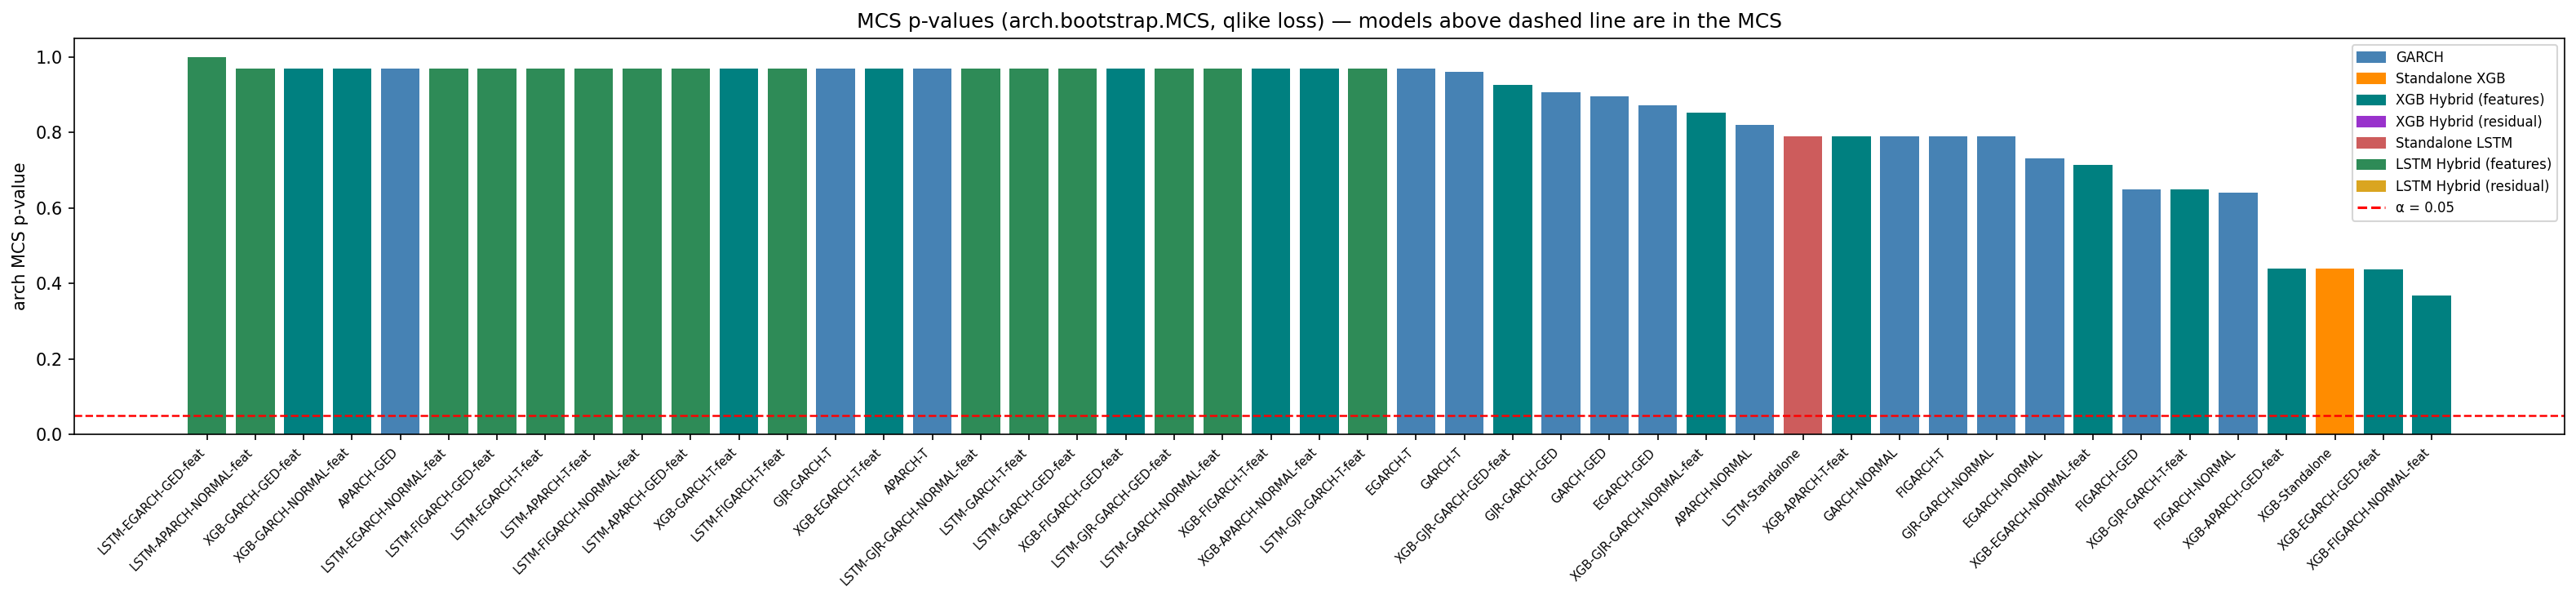

In [42]:
# MCS summary bar chart — arch.bootstrap.MCS p-values per model, coloured by group.
# We plot the arch (graded) p-values rather than our custom-MCS output: the custom
# procedure stops early and assigns a flat placeholder 1.0 to every survivor, which
# would make all in-set bars identical and uninformative. arch gives graded values.
# rename_axis('Model') makes the reset_index column name deterministic regardless of
# how arch names the index.
mcs_df = arch_mcs_result.rename_axis("Model").reset_index()
mcs_df["Group"] = mcs_df["Model"].map(_group)
mcs_df = mcs_df.sort_values("mcs_pvalue", ascending=False)

colors = mcs_df["Group"].map(palette).fillna("gray")

fig, ax = plt.subplots(figsize=(max(8, len(mcs_df) * 0.45), 5), dpi=150)
ax.bar(mcs_df["Model"], mcs_df["mcs_pvalue"], color=colors)
ax.axhline(MCS_ALPHA, color='red', linewidth=1.2, linestyle='--', label=f'α = {MCS_ALPHA}')
ax.set_ylabel("arch MCS p-value")
ax.set_title(f"MCS p-values (arch.bootstrap.MCS, {TEST_LOSS} loss) — models above dashed line are in the MCS")
ax.set_xticklabels(mcs_df["Model"], rotation=45, ha='right', fontsize=7)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [Patch(color=color, label=grp) for grp, color in palette.items()]
legend_elements.append(plt.Line2D([0], [0], color='red', linestyle='--', label=f'α = {MCS_ALPHA}'))
ax.legend(handles=legend_elements, fontsize=8)
plt.tight_layout()
plt.show()